# Pipeline Anti-Spoofing Audio — Bahasa Indonesia

Notebook tunggal yang mencakup seluruh pipeline deteksi deepfake audio:

| Bagian | Deskripsi |
|--------|----------|
| **0** | Setup: install, konfigurasi global, import |
| **1** | Preprocessing audio bona fide (Common Voice) |
| **2** | Generate audio spoof (Edge-TTS, MMS-VITS, gTTS) |
| **3** | Dataset split (train / val / test) |
| **4** | Training model AASIST |
| **5** | Training model MoLEx |
| **6** | Evaluasi komparatif AASIST vs MoLEx |
| **7** | Real-world inference test |
| **8** | Ekstraksi fitur untuk XGBoost |
| **9** | Training & evaluasi XGBoost |

**Untuk menambah dataset baru** (real maupun fake), lihat sel **0.2 Konfigurasi Global**.
> Setelah mengubah konfigurasi, jalankan ulang dari Bagian 1 (preprocessing) atau
> langsung dari Bagian 3 (split) jika file audio sudah tersedia.


---
## Bagian 0 — Setup


### 0.1 Install Dependensi
Jalankan sekali. Lewati jika sudah terinstall.


In [6]:
!pip install --upgrade pip
!pip install librosa soundfile tqdm ipywidgets edge-tts --quiet
!pip install torch torchaudio --index-url https://download.pytorch.org/whl/cpu --quiet
!pip install transformers accelerate --quiet
!pip install xgboost scikit-learn matplotlib joblib --quiet
!pip install omegaconf gtts --quiet
!pip install kokoro>=0.9.2 --quiet
!brew install ffmpeg espeak-ng portaudio --quiet 2>/dev/null || true
!pip install sounddevice --quiet
!pip install --global-option="build_ext" --global-option="-I$(brew --prefix portaudio)/include" --global-option="-L$(brew --prefix portaudio)/lib" pyaudio --quiet 2>/dev/null || pip install pyaudio --quiet 2>/dev/null || true
!pip install "typer<0.13" -q
print("✅ Semua dependensi siap")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.25.0 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
zsh:1: 0.9.2 not found
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer-slim 0.24.0 requires typer>=0.24.0, but you have typer 0.12.5 which is incompatible.
✅ Semua dependensi siap


### 0.2 Konfigurasi Global

> **Sesuaikan variabel di bawah jika ada perubahan path atau penambahan dataset.**

#### Struktur direktori
| Variabel | Path | Keterangan |
|----------|------|------------|
| `CV_CORPUS_ROOT` | `.../dataset` | Corpus sumber — **read-only**, jangan dihapus |
| `DATASET_ROOT` | `.../dataset_voice` | Seluruh output pipeline ini (FLAC, metadata, split, fitur) |
| `MODELS_ROOT` | `.../models_voice` | Checkpoint dan hasil evaluasi model |

#### Menambah dataset bona fide baru
Tambahkan entry baru ke `BONA_FIDE_SOURCES`:
```python
{
    "cv_root"  : f"{CV_CORPUS_ROOT}/cv-corpus-25.0/id",
    "tsv_files": ["validated.tsv"],
    "prefix"   : "cv25_",  # prefix unik agar nama file tidak tabrakan
}
```

#### Menambah sumber spoof baru
- **Edge-TTS**: tambahkan nama suara id-ID ke `EDGE_TTS_VOICES`
- **MMS-VITS / gTTS / Kokoro-82M**: set flag `USE_*` menjadi `True`
- **Custom folder**: tambahkan path ke `EXTRA_SPOOF_DIRS`


In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                  KONFIGURASI GLOBAL                         ║
# ╚══════════════════════════════════════════════════════════════╝
# Semua konstanta didefinisikan di `shared/config.py`.
# Edit file itu untuk mengubah path, voice list, atau hyperparameter.

import sys
sys.path.insert(0, ".")

from shared.config import *
ensure_output_dirs()

print("✅ Konfigurasi global siap")
print(f"  Corpus sumber  : {CV_CORPUS_ROOT}  (read-only)")
print(f"  Dataset output : {DATASET_ROOT}")
print(f"  Models output  : {MODELS_ROOT}")
print()
print(f"  Edge-TTS voices : {EDGE_TTS_VOICES}")
print(f"  MMS-VITS   : {'aktif' if USE_MMS_VITS else 'nonaktif'}")
print(f"  gTTS       : {'aktif' if USE_GTTS else 'nonaktif'} | TLDs: {GTTS_TLD_LIST}")
print(f"  Kokoro-82M : {'aktif' if USE_KOKORO else 'nonaktif'} | voices: {KOKORO_VOICES}")
print(f"  Extra spoof: {EXTRA_SPOOF_DIRS if EXTRA_SPOOF_DIRS else '(tidak ada)'}")


✅ Konfigurasi global siap
  Corpus sumber  : /Users/rey/ITB/semester_2/PPT/dataset  (read-only)
  Dataset output : /Users/rey/ITB/semester_2/PPT/dataset_voice
  Models output  : /Users/rey/ITB/semester_2/PPT/models_voice

  Edge-TTS voices : ['id-ID-GadisNeural', 'id-ID-ArdiNeural']
  MMS-VITS   : aktif
  gTTS       : aktif | TLDs: ['com', 'co.id', 'com.au']
  Kokoro-82M : aktif | voices: ['af_heart', 'af_bella', 'am_adam', 'am_michael']
  Extra spoof: ['/Users/rey/ITB/semester_2/PPT/audio_real_world/fake']


### 0.3 Import Library


In [3]:
# Common imports + torch setup via bootstrap module
from shared.bootstrap import *

# Model & dataset classes (dipakai di Bagian 4-7)
from shared.datasets import AudioDataset, LFCCDataset
from shared.models import AASIST, MoLEx
from shared.feature_extraction import extract_features_from_file

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print("✅ Import selesai")


Device : mps
PyTorch: 2.11.0
✅ Import selesai


---
## Bagian 1 — Preprocessing Audio Bona Fide

Membaca TSV Common Voice, deduplikasi, resample ke 16 kHz, simpan sebagai FLAC.
**Resume-friendly** — file yang sudah ada akan dilewati otomatis.


### 1.1 Baca & Deduplikasi Transkrip


In [1]:
# ── Bootstrap: jalankan bagian ini tanpa re-run cell sebelumnya ──
from shared.bootstrap import *

import librosa
import soundfile as sf


def _read_cv_tsv(path: str) -> list:
    with open(path, "r", encoding="utf-8") as f:
        return list(csv.DictReader(f, delimiter="\t"))


def _preprocess_audio(src: str, dst: str, sr: int = 16000):
    audio, _ = librosa.load(src, sr=sr, mono=True)
    sf.write(dst, audio, sr, format="FLAC", subtype="PCM_16")


# Baca semua sumber bona fide
all_records = {}   # key: (prefix, audio_filename) → record dict

for source in BONA_FIDE_SOURCES:
    cv_root = source["cv_root"]
    prefix  = source.get("prefix", "")
    clips   = os.path.join(cv_root, "clips")
    print(f"\nSumber: {cv_root}")
    print(f"  clips exists : {os.path.exists(clips)}")

    for tsv_name in source["tsv_files"]:
        tsv_path = os.path.join(cv_root, tsv_name)
        if not os.path.exists(tsv_path):
            print(f"  [SKIP] {tsv_name} tidak ditemukan")
            continue
        recs   = _read_cv_tsv(tsv_path)
        before = len(all_records)
        for r in recs:
            key = (prefix, r.get("path", ""))
            if key[1] and key not in all_records:
                r["_clips_dir"] = clips
                r["_prefix"]    = prefix
                all_records[key] = r
        added = len(all_records) - before
        print(f"  {tsv_name}: {len(recs):,} baris, +{added:,} unik ditambahkan")

print(f"\n📦 Total unik: {len(all_records):,} rekaman")



Sumber: /Users/rey/ITB/semester_2/PPT/dataset/cv-corpus-24.0-2025-12-05/id
  clips exists : True
  validated.tsv: 30,256 baris, +30,256 unik ditambahkan
  train.tsv: 4,973 baris, +0 unik ditambahkan
  test.tsv: 3,691 baris, +0 unik ditambahkan

Sumber: /Users/rey/ITB/semester_2/PPT/dataset/librivox-id
  clips exists : True
  validated.tsv: 5,635 baris, +5,635 unik ditambahkan

Sumber: /Users/rey/ITB/semester_2/PPT/dataset/octava-id
  clips exists : True
  validated.tsv: 26,964 baris, +26,964 unik ditambahkan

📦 Total unik: 62,855 rekaman


### 1.2 Jalankan Preprocessing
> ⏳ Proses ini bisa lama. Progress bar akan muncul di bawah.
> Script ini **resume-friendly** — jalankan ulang dan file yang sudah ada dilewati.


In [2]:
processed, skipped = 0, 0

with open(META_BONA_FIDE, "w", encoding="utf-8", newline="") as meta_f:
    writer = csv.writer(meta_f, delimiter="\t")
    writer.writerow(["file_id", "flac_filename", "sentence"])

    for (prefix, audio_filename), record in tqdm(all_records.items(),
                                                  desc="Preprocessing", unit="file"):
        clips_dir  = record["_clips_dir"]
        input_path = os.path.join(clips_dir, audio_filename)
        if not os.path.exists(input_path):
            skipped += 1
            continue

        stem          = prefix + Path(audio_filename).stem
        flac_filename = stem + ".flac"
        output_path   = os.path.join(DIR_BONA_FIDE, flac_filename)
        sentence      = record.get("sentence", "").strip()

        if os.path.exists(output_path):   # resume-friendly
            writer.writerow([stem, flac_filename, sentence])
            processed += 1
            continue

        try:
            _preprocess_audio(input_path, output_path, SAMPLE_RATE)
            writer.writerow([stem, flac_filename, sentence])
            processed += 1
        except Exception as e:
            print(f"\n[ERROR] {audio_filename}: {e}")
            skipped += 1

print(f"\n✅ Selesai!")
print(f"   Berhasil : {processed:,} | Dilewati/error : {skipped:,}")
print(f"   Output   : {DIR_BONA_FIDE}/")
print(f"   Metadata : {META_BONA_FIDE}")


Preprocessing:   0%|          | 0/62855 [00:00<?, ?file/s]


✅ Selesai!
   Berhasil : 62,855 | Dilewati/error : 0
   Output   : /Users/rey/ITB/semester_2/PPT/dataset_voice/bona_fide/
   Metadata : /Users/rey/ITB/semester_2/PPT/dataset_voice/metadata_bona_fide.tsv


In [3]:
# Tambahkan file bona fide dari folder eksternal (EXTRA_BONA_FIDE_DIRS)
# Konversi MP3/MP4 → FLAC dan salin ke DIR_BONA_FIDE, lalu append ke META_BONA_FIDE
import re

extra_bf_added = 0
with open(META_BONA_FIDE, "a", encoding="utf-8", newline="") as meta_f:
    writer = csv.writer(meta_f, delimiter="\t")
    for extra_dir in EXTRA_BONA_FIDE_DIRS:
        for ext in ("*.flac", "*.wav", "*.mp3", "*.mp4"):
            for p in Path(extra_dir).glob(ext):
                stem = re.sub(r'[^\w]', '_', p.stem)
                flac_filename = stem + ".flac"
                dst = Path(DIR_BONA_FIDE) / flac_filename
                if not dst.exists():
                    audio, _ = librosa.load(str(p), sr=SAMPLE_RATE, mono=True)
                    sf.write(str(dst), audio, SAMPLE_RATE, format="FLAC", subtype="PCM_16")
                writer.writerow([stem, flac_filename, ""])
                extra_bf_added += 1

print(f"✅ Ditambahkan {extra_bf_added} file bona fide dari EXTRA_BONA_FIDE_DIRS")


✅ Ditambahkan 34 file bona fide dari EXTRA_BONA_FIDE_DIRS


### 1.3 Verifikasi Hasil


In [4]:
flac_files = list(Path(DIR_BONA_FIDE).glob("*.flac"))
print(f"Total FLAC bona fide: {len(flac_files):,}")

print("\nSampel verifikasi (3 file acak):")
for p in random.sample(flac_files, min(3, len(flac_files))):
    audio, sr = librosa.load(str(p), sr=None)
    dur = len(audio) / sr
    ok  = "✅" if sr == SAMPLE_RATE else "❌"
    print(f"  {p.name:40s} | sr={sr}Hz {ok} | dur={dur:.2f}s")

print(f"\nPreview metadata:")
with open(META_BONA_FIDE) as f:
    for i, line in enumerate(f):
        print(f"  {line.rstrip()}")
        if i >= 4: print("  ..."); break


Total FLAC bona fide: 62,889

Sampel verifikasi (3 file acak):
  common_voice_id_26265064.flac            | sr=16000Hz ✅ | dur=6.19s
  common_voice_id_25350218.flac            | sr=16000Hz ✅ | dur=3.02s
  octava_25063.flac                        | sr=16000Hz ✅ | dur=5.57s

Preview metadata:
  file_id	flac_filename	sentence
  common_voice_id_39599471	common_voice_id_39599471.flac	Dia tidak sepenuhnya mempercayaiku.
  common_voice_id_32165882	common_voice_id_32165882.flac	Aku juga tidak mengerti.
  common_voice_id_27657418	common_voice_id_27657418.flac	Berharap kau di sini.
  common_voice_id_23033570	common_voice_id_23033570.flac	Maha Suci Allah.
  ...


---
## Bagian 2 — Generate Audio Spoof

Empat opsi pembangkit spoof (dikontrol dari Konfigurasi Global):
1. **Edge-TTS** (default, online, cepat) — `EDGE_TTS_VOICES`
2. **MMS-VITS** (opsional, offline) — `USE_MMS_VITS = True`
3. **gTTS** (opsional, online) — `USE_GTTS = True`
4. **Kokoro-82M** (opsional, offline, neural TTS) — `USE_KOKORO = True`

Tambah folder deepfake eksternal via `EXTRA_SPOOF_DIRS`.


### 2.1 Baca Metadata Bona Fide


In [13]:
# ── Bootstrap: jalankan bagian ini tanpa re-run cell sebelumnya ──
from shared.bootstrap import *

# Prefix sumber yang dikecualikan dari generate spoof
SPOOF_EXCLUDE_PREFIXES = ("librivox_",)

bf_records = []
with open(META_BONA_FIDE, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f, delimiter="\t"):
        if row.get("sentence", "").strip():
            bf_records.append(row)

# bf_records untuk TTS — kecualikan sumber dengan ejaan/bahasa tidak kompatibel
bf_tts_records = [
    r for r in bf_records
    if not r["file_id"].startswith(SPOOF_EXCLUDE_PREFIXES)
]

print(f"Total rekaman bona fide  : {len(bf_records):,}")
print(f"Dikecualikan dari TTS    : {len(bf_records) - len(bf_tts_records):,} (librivox)")
print(f"Target spoof edge-tts    : {len(bf_tts_records) * len(EDGE_TTS_VOICES):,}")

print("\nPreview:")
for r in bf_tts_records[:3]:
    print(f"  {r['file_id']:40s} | {r['sentence'][:55]}")


Total rekaman bona fide  : 35,891
Dikecualikan dari TTS    : 5,635 (librivox)
Target spoof edge-tts    : 60,512

Preview:
  common_voice_id_39599471                 | Dia tidak sepenuhnya mempercayaiku.
  common_voice_id_32165882                 | Aku juga tidak mengerti.
  common_voice_id_27657418                 | Berharap kau di sini.


### 2.2 Edge-TTS (GadisNeural & ArdiNeural)


In [8]:
import edge_tts


async def _gen_tts(text: str, voice: str, mp3_path: str):
    await edge_tts.Communicate(text, voice).save(mp3_path)


async def _process_tts_one(record, voice, rows, lock, sem):
    """Proses satu pasangan (transkrip, voice) → FLAC spoof."""
    file_id       = record["file_id"]
    sentence      = record["sentence"].strip()
    voice_tag     = voice.replace("-", "_").lower()
    flac_filename = f"{file_id}_{voice_tag}.flac"
    flac_path     = os.path.join(DIR_SPOOF, flac_filename)

    if os.path.exists(flac_path):   # resume-friendly
        async with lock:
            rows.append([file_id, flac_filename, sentence, voice])
        return

    async with sem:
        with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as tmp:
            tmp_mp3 = tmp.name
        try:
            await _gen_tts(sentence, voice, tmp_mp3)
            audio, _ = librosa.load(tmp_mp3, sr=SAMPLE_RATE, mono=True)
            sf.write(flac_path, audio, SAMPLE_RATE, format="FLAC", subtype="PCM_16")
            async with lock:
                rows.append([file_id, flac_filename, sentence, voice])
        except Exception as e:
            print(f"\n[ERROR TTS] {file_id}|{voice}: {e}")
        finally:
            if os.path.exists(tmp_mp3):
                os.remove(tmp_mp3)


sem      = asyncio.Semaphore(EDGE_TTS_CONCURRENCY)
lock     = asyncio.Lock()
rows_tts = []

tasks = [
    _process_tts_one(rec, voice, rows_tts, lock, sem)
    for rec   in bf_tts_records
    for voice in EDGE_TTS_VOICES
]

pbar = tqdm(total=len(tasks), desc="Edge-TTS", unit="file")
for coro in asyncio.as_completed(tasks):
    await coro
    pbar.update(1)
pbar.close()

print(f"✅ Edge-TTS selesai: {len(rows_tts):,} file")


Edge-TTS:   0%|          | 0/60512 [00:00<?, ?file/s]

✅ Edge-TTS selesai: 60,512 file


### 2.3 MMS-VITS — Facebook (opsional)


In [9]:
rows_vits = []

if USE_MMS_VITS:
    from transformers import pipeline as hf_pipeline

    # ── Checkpoint: simpan daftar sample agar resume konsisten ───────────
    import json as _json
    _queue_path = os.path.join(DIR_SPOOF, "_mms_vits_queue.json")

    if os.path.exists(_queue_path):
        with open(_queue_path) as _f:
            vits_sample = _json.load(_f)
        print(f"▶️  Resume dari checkpoint: {len(vits_sample):,} item dalam antrian")
    else:
        vits_sample = random.sample(bf_tts_records, min(MMS_VITS_NSAMPLES, len(bf_tts_records)))
        with open(_queue_path, "w") as _f:
            _json.dump(vits_sample, _f, ensure_ascii=False)
        print(f"🆕 Antrian baru dibuat: {len(vits_sample):,} item")

    _done = sum(
        1 for r in vits_sample
        if os.path.exists(os.path.join(DIR_SPOOF, f"{r['file_id']}_mms_vits.flac"))
    )
    print(f"   Sudah selesai : {_done:,} / {len(vits_sample):,}")
    print(f"   Sisa          : {len(vits_sample) - _done:,}")

    print("Loading facebook/mms-tts-ind...")
    mms = hf_pipeline("text-to-speech", model="facebook/mms-tts-ind", device="cpu")

    for r in tqdm(vits_sample, desc="MMS-VITS"):
        file_id       = r["file_id"]
        sentence      = r["sentence"].strip()
        flac_filename = f"{file_id}_mms_vits.flac"
        flac_path     = os.path.join(DIR_SPOOF, flac_filename)

        if os.path.exists(flac_path):
            rows_vits.append([file_id, flac_filename, sentence, "mms_vits"])
            continue
        try:
            out = mms(sentence)
            arr = np.squeeze(out["audio"]).astype("float32")
            sr_o = out["sampling_rate"]
            if sr_o != SAMPLE_RATE:
                arr = librosa.resample(arr, orig_sr=sr_o, target_sr=SAMPLE_RATE)
            sf.write(flac_path, arr, SAMPLE_RATE, format="FLAC", subtype="PCM_16")
            rows_vits.append([file_id, flac_filename, sentence, "mms_vits"])
        except Exception as e:
            print(f"\n[ERROR MMS-VITS] {file_id}: {e}")

    # ── Hapus checkpoint jika semua selesai ───────────────────────────────
    if len(rows_vits) == len(vits_sample):
        os.remove(_queue_path)
        print(f"✅ MMS-VITS selesai: {len(rows_vits):,} file — checkpoint dihapus")
    else:
        _remaining = len(vits_sample) - len(rows_vits)
        print(f"⚠️  MMS-VITS: {len(rows_vits):,} file berhasil, {_remaining:,} gagal/belum — jalankan ulang untuk resume")
else:
    print("⏭️  MMS-VITS nonaktif (set USE_MMS_VITS=True di Konfigurasi Global)")


▶️  Resume dari checkpoint: 5,000 item dalam antrian
   Sudah selesai : 4,999 / 5,000
   Sisa          : 1
Loading facebook/mms-tts-ind...


Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

MMS-VITS:   0%|          | 0/5000 [00:00<?, ?it/s]

✅ MMS-VITS selesai: 5,000 file — checkpoint dihapus


In [10]:
# Bebaskan memori setelah MMS-VITS agar tidak OOM saat training
if USE_MMS_VITS and "vits_pipe" in dir():
    del vits_pipe
import gc; gc.collect()
try:
    import torch
    if hasattr(torch.mps, "empty_cache"): torch.mps.empty_cache()
except Exception:
    pass
print("Memori MMS-VITS dibebaskan")

Memori MMS-VITS dibebaskan


### 2.4 gTTS (opsional)

In [11]:
import time
from gtts import gTTS

rows_gtts = []

if USE_GTTS:
    import json as _json

    # ── Checkpoint: simpan daftar sample + tld assignment ────────────────
    # Queue disimpan agar re-run menggunakan sampel yang SAMA (resume-friendly)
    _queue_path = os.path.join(DIR_SPOOF, "_gtts_queue.json")

    if os.path.exists(_queue_path):
        with open(_queue_path) as _f:
            gtts_queue = _json.load(_f)
        print(f"▶️  Resume dari checkpoint: {len(gtts_queue):,} item dalam antrian")
    else:
        gtts_sample = random.sample(bf_tts_records, min(GTTS_NSAMPLES, len(bf_tts_records)))
        gtts_queue  = [
            {**r, "tld": GTTS_TLD_LIST[i % len(GTTS_TLD_LIST)]}
            for i, r in enumerate(gtts_sample)
        ]
        with open(_queue_path, "w") as _f:
            _json.dump(gtts_queue, _f, ensure_ascii=False)
        print(f"🆕 Antrian baru dibuat: {len(gtts_queue):,} item")

    _done = sum(
        1 for r in gtts_queue
        if os.path.exists(os.path.join(DIR_SPOOF,
               f"{r['file_id']}_gtts_{r['tld'].replace('.', '_')}.flac"))
    )
    print(f"   Sudah selesai : {_done:,} / {len(gtts_queue):,}")
    print(f"   Sisa          : {len(gtts_queue) - _done:,}")

    for r in tqdm(gtts_queue, desc="gTTS"):
        file_id       = r["file_id"]
        sentence      = r["sentence"].strip()
        tld           = r["tld"]
        flac_filename = f"{file_id}_gtts_{tld.replace('.', '_')}.flac"
        flac_path     = os.path.join(DIR_SPOOF, flac_filename)

        if os.path.exists(flac_path):
            rows_gtts.append([file_id, flac_filename, sentence, f"gtts_{tld}"])
            continue

        tmp_path = None
        for attempt in range(3):
            try:
                tts = gTTS(text=sentence, lang="id", tld=tld)
                with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as tmp:
                    tmp_path = tmp.name
                tts.save(tmp_path)
                arr, _ = librosa.load(tmp_path, sr=SAMPLE_RATE, mono=True)
                os.remove(tmp_path)
                tmp_path = None
                sf.write(flac_path, arr, SAMPLE_RATE, format="FLAC", subtype="PCM_16")
                rows_gtts.append([file_id, flac_filename, sentence, f"gtts_{tld}"])
                time.sleep(GTTS_REQUEST_DELAY)
                break
            except Exception as e:
                if tmp_path and os.path.exists(tmp_path):
                    os.remove(tmp_path)
                    tmp_path = None
                if attempt < 2:
                    time.sleep(1.0 * (attempt + 1))
                else:
                    print(f"[ERROR gTTS] {file_id} (tld={tld}): {e}")

    # ── Hapus checkpoint jika semua selesai ──────────────────────────────
    if len(rows_gtts) == len(gtts_queue):
        os.remove(_queue_path)
        print(f"✅ gTTS selesai: {len(rows_gtts):,} file — checkpoint dihapus")
    else:
        _remaining = len(gtts_queue) - len(rows_gtts)
        print(f"⚠️  gTTS: {len(rows_gtts):,} file berhasil, {_remaining:,} gagal/belum — jalankan ulang untuk resume")
else:
    print("⏭️  gTTS nonaktif (set USE_GTTS=True di Konfigurasi Global)")

🆕 Antrian baru dibuat: 5,000 item
   Sudah selesai : 770 / 5,000
   Sisa          : 4,230


gTTS:   0%|          | 0/5000 [00:00<?, ?it/s]

✅ gTTS selesai: 5,000 file — checkpoint dihapus


### 2.5 Kokoro-82M (opsional)

In [12]:
rows_kokoro = []

if USE_KOKORO:
    import subprocess as _sp, platform as _pl, json as _json
    import numpy as _np

    # ── Instalasi dependensi Kokoro ───────────────────────────────────────
    _sp.run([sys.executable, "-m", "pip", "install", "kokoro>=0.9.2", "--quiet"], check=True)
    # espeak-ng diperlukan Kokoro untuk konversi teks → fonem
    if _pl.system() == "Darwin":
        _sp.run(["brew", "install", "espeak-ng"], capture_output=True)
    else:
        _sp.run(["apt-get", "-qq", "-y", "install", "espeak-ng"],
                capture_output=True, check=False)

    from kokoro import KPipeline

    # ── Checkpoint: simpan daftar sample + voice assignment ──────────────
    _queue_path = os.path.join(DIR_SPOOF, "_kokoro_queue.json")

    if os.path.exists(_queue_path):
        with open(_queue_path) as _f:
            kokoro_queue = _json.load(_f)
        print(f"▶️  Resume dari checkpoint: {len(kokoro_queue):,} item dalam antrian")
    else:
        kokoro_sample = random.sample(bf_tts_records, min(KOKORO_NSAMPLES, len(bf_tts_records)))
        kokoro_queue  = [
            {**r, "voice": KOKORO_VOICES[i % len(KOKORO_VOICES)]}
            for i, r in enumerate(kokoro_sample)
        ]
        with open(_queue_path, "w") as _f:
            _json.dump(kokoro_queue, _f, ensure_ascii=False)
        print(f"🆕 Antrian baru dibuat: {len(kokoro_queue):,} item")

    _done = sum(
        1 for r in kokoro_queue
        if os.path.exists(os.path.join(DIR_SPOOF,
               f"{r['file_id']}_kokoro_{r['voice']}.flac"))
    )
    print(f"   Sudah selesai : {_done:,} / {len(kokoro_queue):,}")
    print(f"   Sisa          : {len(kokoro_queue) - _done:,}")

    print(f"Loading Kokoro-82M (lang={KOKORO_LANG_CODE!r}, {len(KOKORO_VOICES)} voices)...")
    koko_pipe = KPipeline(lang_code=KOKORO_LANG_CODE)

    for r in tqdm(kokoro_queue, desc="Kokoro-82M"):
        file_id       = r["file_id"]
        sentence      = r["sentence"].strip()
        voice         = r["voice"]
        flac_filename = f"{file_id}_kokoro_{voice}.flac"
        flac_path     = os.path.join(DIR_SPOOF, flac_filename)

        if os.path.exists(flac_path):
            rows_kokoro.append([file_id, flac_filename, sentence, f"kokoro_{voice}"])
            continue

        try:
            chunks = [audio for _, _, audio in koko_pipe(sentence, voice=voice)]
            if not chunks:
                raise ValueError("Kokoro menghasilkan audio kosong")
            arr = _np.concatenate(chunks).astype("float32")
            # Resample 24 kHz (native Kokoro) → SAMPLE_RATE
            arr = librosa.resample(arr, orig_sr=24000, target_sr=SAMPLE_RATE)
            sf.write(flac_path, arr, SAMPLE_RATE, format="FLAC", subtype="PCM_16")
            rows_kokoro.append([file_id, flac_filename, sentence, f"kokoro_{voice}"])
        except Exception as e:
            print(f"\n[ERROR Kokoro] {file_id} (voice={voice}): {e}")

    # ── Hapus checkpoint jika semua selesai ──────────────────────────────
    if len(rows_kokoro) == len(kokoro_queue):
        os.remove(_queue_path)
        print(f"✅ Kokoro-82M selesai: {len(rows_kokoro):,} file — checkpoint dihapus")
    else:
        _remaining = len(kokoro_queue) - len(rows_kokoro)
        print(f"⚠️  Kokoro-82M: {len(rows_kokoro):,} file berhasil, {_remaining:,} gagal/belum — jalankan ulang untuk resume")
else:
    print("⏭️  Kokoro-82M nonaktif (set USE_KOKORO=True di Konfigurasi Global)")


🆕 Antrian baru dibuat: 5,000 item
   Sudah selesai : 401 / 5,000
   Sisa          : 4,599
Loading Kokoro-82M (lang='a', 4 voices)...


Kokoro-82M:   0%|          | 0/5000 [00:00<?, ?it/s]

✅ Kokoro-82M selesai: 5,000 file — checkpoint dihapus


In [13]:
# Bebaskan memori setelah Kokoro agar tidak OOM saat training
if USE_KOKORO and "koko_pipe" in dir():
    del koko_pipe
import gc; gc.collect()
try:
    import torch
    if hasattr(torch.mps, "empty_cache"): torch.mps.empty_cache()
except Exception:
    pass
print("Memori Kokoro dibebaskan")

Memori Kokoro dibebaskan


### 2.6 Tulis Metadata Spoof & Verifikasi

In [19]:
# Gabung semua sumber spoof
# Fallback ke [] jika cell generator dilewati
rows_tts    = locals().get("rows_tts",    [])
rows_vits   = locals().get("rows_vits",   [])
rows_gtts   = locals().get("rows_gtts",   [])
rows_kokoro = locals().get("rows_kokoro", [])
all_spoof_rows = rows_tts + rows_vits + rows_gtts + rows_kokoro

# Resume-friendly: baca metadata lama, gabungkan dengan rows session ini
# Rows dari session (TTS baru) selalu menang atas entri lama
if os.path.exists(META_SPOOF):
    with open(META_SPOOF, "r", encoding="utf-8") as _f:
        _existing = [[r["file_id"], r["flac_filename"], r.get("sentence",""), r.get("tts_voice","")]
                     for r in csv.DictReader(_f, delimiter="\t")]
    _session_ids = {r[0] for r in all_spoof_rows}
    all_spoof_rows += [r for r in _existing if r[0] not in _session_ids]


import re
# Tambahkan file dari folder eksternal (EXTRA_SPOOF_DIRS)
# Konversi MP3/MP4 → FLAC dan salin ke DIR_SPOOF
for extra_dir in EXTRA_SPOOF_DIRS:
    label = f"extra:{Path(extra_dir).name}"
    for ext in ("*.flac", "*.wav", "*.mp3", "*.mp4"):
        for p in Path(extra_dir).glob(ext):
            stem = re.sub(r'[^\w]', '_', p.stem)
            flac_filename = stem + ".flac"
            dst = Path(DIR_SPOOF) / flac_filename
            if not dst.exists():
                audio, _ = librosa.load(str(p), sr=SAMPLE_RATE, mono=True)
                sf.write(str(dst), audio, SAMPLE_RATE, format="FLAC", subtype="PCM_16")
            all_spoof_rows.append([stem, flac_filename, "", label])

with open(META_SPOOF, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f, delimiter="\t")
    writer.writerow(["file_id", "flac_filename", "sentence", "tts_voice"])
    writer.writerows(all_spoof_rows)

print(f"✅ Metadata spoof: {len(all_spoof_rows):,} entri → {META_SPOOF}")

voice_counts = Counter(r[3] for r in all_spoof_rows)
print("\nJumlah per voice/sumber:")
for v, cnt in sorted(voice_counts.items()):
    print(f"  {v:40s}: {cnt:,}")


✅ Metadata spoof: 111,032 entri → /Users/rey/ITB/semester_2/PPT/dataset_voice/metadata_spoof.tsv

Jumlah per voice/sumber:
  extra:fake                              : 28
  gtts_co.id                              : 7,307
  gtts_com                                : 7,300
  gtts_com.au                             : 7,301
  id-ID-ArdiNeural                        : 30,256
  id-ID-GadisNeural                       : 30,256
  kokoro_af_bella                         : 5,887
  kokoro_af_heart                         : 5,894
  kokoro_am_adam                          : 5,905
  kokoro_am_michael                       : 5,894
  mms_vits                                : 5,004


---
## Bagian 3 — Dataset Split

Balancing 1:1 (subsample kelas yang lebih banyak), lalu split train/val/test.
**Jalankan ulang bagian ini setiap kali ada penambahan data.**


### 3.1 Load Metadata


In [5]:
# ── Bootstrap: jalankan bagian ini tanpa re-run cell sebelumnya ──
from shared.bootstrap import *

def _read_meta(path: str) -> list:
    with open(path, "r", encoding="utf-8") as f:
        return list(csv.DictReader(f, delimiter="\t"))

bf_recs    = _read_meta(META_BONA_FIDE)
spoof_recs = _read_meta(META_SPOOF)

print(f"Bona-fide records : {len(bf_recs):,}")
print(f"Spoof records     : {len(spoof_recs):,}")


Bona-fide records : 62,889
Spoof records     : 111,032


### 3.2 Balance, Gabung & Split


In [6]:
random.seed(42)

n_balanced = min(len(bf_recs), len(spoof_recs))
bf_bal     = random.sample(bf_recs,    n_balanced)
sp_bal     = random.sample(spoof_recs, n_balanced)
print(f"Setelah balancing: {n_balanced:,} bona-fide + {n_balanced:,} spoof")


def _make_entry(record: dict, label: str, audio_dir: str) -> dict:
    return {
        "file_id"      : record["file_id"],
        "file_path"    : os.path.join(audio_dir, record["flac_filename"]),
        "flac_filename": record["flac_filename"],
        "label"        : label,
        "sentence"     : record.get("sentence", ""),
    }


all_entries = (
    [_make_entry(r, "bonafide", DIR_BONA_FIDE) for r in bf_bal] +
    [_make_entry(r, "spoof",    DIR_SPOOF)     for r in sp_bal]
)
random.shuffle(all_entries)

N       = len(all_entries)
n_train = int(N * RATIO_TRAIN)
n_val   = int(N * RATIO_VAL)

split_train = all_entries[:n_train]
split_val   = all_entries[n_train : n_train + n_val]
split_test  = all_entries[n_train + n_val:]

print(f"Train : {len(split_train):,} ({len(split_train)/N*100:.1f}%)")
print(f"Val   : {len(split_val):,} ({len(split_val)/N*100:.1f}%)")
print(f"Test  : {len(split_test):,} ({len(split_test)/N*100:.1f}%)")


Setelah balancing: 62,889 bona-fide + 62,889 spoof
Train : 100,622 (80.0%)
Val   : 12,577 (10.0%)
Test  : 12,579 (10.0%)


### 3.3 Simpan Split TSV


In [7]:
FIELDNAMES = ["file_id", "file_path", "flac_filename", "label", "sentence"]

for split_name, entries in [("train", split_train), ("val", split_val), ("test", split_test)]:
    out_path = os.path.join(SPLITS_DIR, f"{split_name}.tsv")
    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=FIELDNAMES, delimiter="\t", extrasaction="ignore")
        w.writeheader()
        w.writerows(entries)
    cnt = Counter(e["label"] for e in entries)
    print(f"✅ {split_name}.tsv ({len(entries):,}) — bonafide={cnt['bonafide']:,} spoof={cnt['spoof']:,}")

print(f"\nSplit tersimpan di: {SPLITS_DIR}")


✅ train.tsv (100,622) — bonafide=50,264 spoof=50,358
✅ val.tsv (12,577) — bonafide=6,291 spoof=6,286
✅ test.tsv (12,579) — bonafide=6,334 spoof=6,245

Split tersimpan di: /Users/rey/ITB/semester_2/PPT/dataset_voice/splits


---
## Bagian 4 — Training AASIST

AASIST-lite: SincConv → ResBlock encoder → AdaptiveAvgPool → Classifier.
Input: raw waveform 4 detik @ 16 kHz.


### 4.1 Dataset & DataLoader


In [8]:
# ── Bootstrap: jalankan bagian ini tanpa re-run cell sebelumnya ──
from shared.bootstrap import *
from shared.datasets import AudioDataset, LFCCDataset
from shared.models import AASIST, MoLEx

train_ds_a = AudioDataset(f"{SPLITS_DIR}/train.tsv", MAX_SAMPLES, SAMPLE_RATE)
val_ds_a   = AudioDataset(f"{SPLITS_DIR}/val.tsv",   MAX_SAMPLES, SAMPLE_RATE)
test_ds_a  = AudioDataset(f"{SPLITS_DIR}/test.tsv",  MAX_SAMPLES, SAMPLE_RATE)

train_dl_a = DataLoader(train_ds_a, BATCH_SIZE_AASIST, shuffle=True,  num_workers=NUM_WORKERS)
val_dl_a   = DataLoader(val_ds_a,   BATCH_SIZE_AASIST, shuffle=False, num_workers=NUM_WORKERS)
test_dl_a  = DataLoader(test_ds_a,  BATCH_SIZE_AASIST, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train:{len(train_ds_a):,} | Val:{len(val_ds_a):,} | Test:{len(test_ds_a):,}")
x, y = train_ds_a[0]
print(f"Waveform shape : {x.shape} | label : {y.item()}")


Train:100,622 | Val:12,577 | Test:12,579
Waveform shape : torch.Size([64000]) | label : 1


### 4.2 Setup Model


In [9]:
aasist_model  = AASIST().to(DEVICE)
aasist_crit   = nn.CrossEntropyLoss()
aasist_optim  = optim.AdamW(aasist_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
aasist_sched  = optim.lr_scheduler.CosineAnnealingLR(aasist_optim, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"Total params : {sum(p.numel() for p in aasist_model.parameters()):,}")
with torch.no_grad():
    print(f"Output shape : {aasist_model(torch.randn(2, MAX_SAMPLES).to(DEVICE)).shape} ✅")


Total params : 2,508,174
Output shape : torch.Size([2, 2]) ✅


### 4.3 Training Loop


In [10]:
aasist_history   = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_aasist_acc  = 0.0
patience_ctr_a   = 0
aasist_ckpt      = f"{DIR_AASIST}/aasist_best.pt"

print(f"Training AASIST {NUM_EPOCHS} epoch...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(aasist_model, train_dl_a, aasist_crit, aasist_optim, DEVICE)
    vl_loss, vl_acc = run_epoch(aasist_model, val_dl_a,   aasist_crit, device=DEVICE)
    aasist_sched.step()

    for k, v in [("train_loss", tr_loss), ("train_acc", tr_acc),
                  ("val_loss",   vl_loss), ("val_acc",   vl_acc)]:
        aasist_history[k].append(v)

    flag = ""
    if vl_acc > best_aasist_acc:
        best_aasist_acc = vl_acc
        torch.save(aasist_model.state_dict(), aasist_ckpt)
        patience_ctr_a = 0
        flag = " ✅ best"
    else:
        patience_ctr_a += 1

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"Val loss={vl_loss:.4f} acc={vl_acc:.4f}{flag}")

    if patience_ctr_a >= PATIENCE:
        print(f"Early stopping setelah {PATIENCE} epoch tanpa peningkatan.")
        break

json.dump(aasist_history, open(f"{DIR_AASIST}/history.json", "w"), indent=2)
print(f"\n✅ AASIST selesai. Best val acc: {best_aasist_acc:.4f}")


Training AASIST 20 epoch...

Epoch 01/20 | Train loss=0.0840 acc=0.9687 | Val loss=1.4641 acc=0.7650 ✅ best
Epoch 02/20 | Train loss=0.0185 acc=0.9952 | Val loss=0.0338 acc=0.9865 ✅ best
Epoch 03/20 | Train loss=0.0126 acc=0.9966 | Val loss=3.4743 acc=0.7335
Epoch 04/20 | Train loss=0.0088 acc=0.9976 | Val loss=0.0464 acc=0.9820
Epoch 05/20 | Train loss=0.0065 acc=0.9985 | Val loss=5.9977 acc=0.5976
Epoch 06/20 | Train loss=0.0055 acc=0.9987 | Val loss=8.0042 acc=0.6315
Epoch 07/20 | Train loss=0.0039 acc=0.9991 | Val loss=0.6539 acc=0.9171
Early stopping setelah 5 epoch tanpa peningkatan.

✅ AASIST selesai. Best val acc: 0.9865


### 4.4 Plot Learning Curve


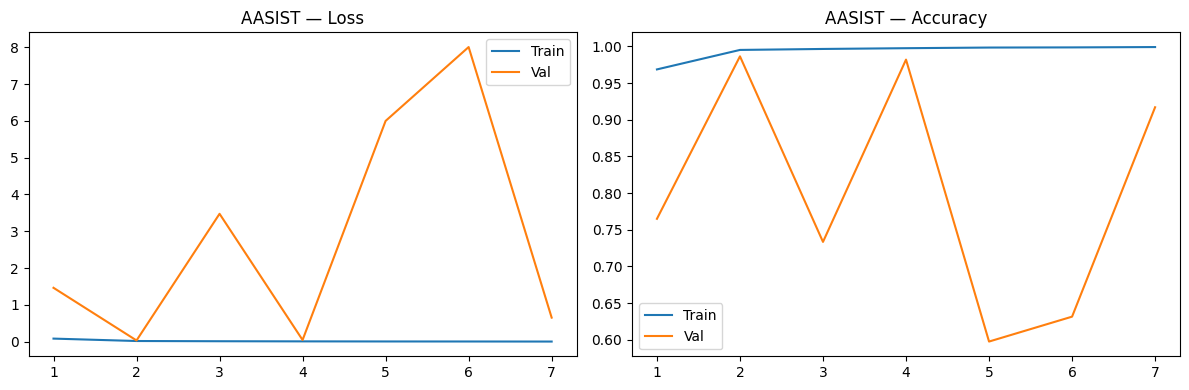

In [11]:
_ep = range(1, len(aasist_history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(_ep, aasist_history["train_loss"], label="Train")
axes[0].plot(_ep, aasist_history["val_loss"],   label="Val")
axes[0].set_title("AASIST — Loss"); axes[0].legend()
axes[1].plot(_ep, aasist_history["train_acc"],  label="Train")
axes[1].plot(_ep, aasist_history["val_acc"],    label="Val")
axes[1].set_title("AASIST — Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{DIR_AASIST}/training_curve.png", dpi=150); plt.show()


### 4.5 Evaluasi Test Set


In [12]:
import time
from sklearn.metrics import classification_report

aasist_model.load_state_dict(torch.load(aasist_ckpt, map_location=DEVICE))
aasist_model.eval()

a_preds, a_labels, a_probs = [], [], []
t0 = time.perf_counter()
with torch.no_grad():
    for wf, lab in tqdm(test_dl_a, desc="AASIST test"):
        logits = aasist_model(wf.to(DEVICE))
        a_probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        a_preds.extend(logits.argmax(1).cpu().numpy())
        a_labels.extend(lab.numpy())
a_infer_time = time.perf_counter() - t0

a_labels, a_preds, a_probs = map(np.array, [a_labels, a_preds, a_probs])
aasist_metrics = compute_metrics(a_labels, a_preds, a_probs)
aasist_metrics["infer_time_s"]        = round(a_infer_time, 4)
aasist_metrics["infer_ms_per_sample"] = round(a_infer_time / len(a_labels) * 1000, 4)

print(classification_report(a_labels, a_preds, target_names=["bonafide", "spoof"]))
print(f"ROC-AUC      : {aasist_metrics['roc_auc']:.4f}")
print(f"EER          : {aasist_metrics['eer']*100:.2f}%")
print(f"MCC          : {aasist_metrics['mcc']:.4f}")
print(f"Waktu inf.   : {a_infer_time*1000:.1f} ms total  |  "
      f"{aasist_metrics['infer_ms_per_sample']:.4f} ms/sampel")
json.dump(aasist_metrics, open(f"{DIR_AASIST}/test_results.json", "w"), indent=2)
np.savez(f"{DIR_AASIST}/test_predictions.npz",
         labels=a_labels, preds=a_preds, probs=a_probs)


AASIST test:   0%|          | 0/525 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    bonafide       0.98      1.00      0.99      6334
       spoof       1.00      0.98      0.99      6245

    accuracy                           0.99     12579
   macro avg       0.99      0.99      0.99     12579
weighted avg       0.99      0.99      0.99     12579

ROC-AUC      : 0.9998
EER          : 0.43%
MCC          : 0.9762
Waktu inf.   : 59432.6 ms total  |  4.7247 ms/sampel


---
## Bagian 5 — Training MoLEx

MoLEx: LCNN (Light CNN) + Attention Pooling pada fitur LFCC.
Input: LFCC features [n_lfcc=60, frames].


### 5.1 Dataset & DataLoader


In [13]:
# ── Bootstrap: jalankan bagian ini tanpa re-run cell sebelumnya ──
from shared.bootstrap import *
from shared.datasets import AudioDataset, LFCCDataset
from shared.models import AASIST, MoLEx

lfcc_kwargs = dict(
    n_lfcc=N_LFCC, n_filter=N_FILTER, n_fft=N_FFT,
    win_length=WIN_LENGTH, hop_length=HOP_LENGTH,
)

train_ds_m = LFCCDataset(f"{SPLITS_DIR}/train.tsv", MAX_SAMPLES, SAMPLE_RATE, **lfcc_kwargs)
val_ds_m   = LFCCDataset(f"{SPLITS_DIR}/val.tsv",   MAX_SAMPLES, SAMPLE_RATE, **lfcc_kwargs)
test_ds_m  = LFCCDataset(f"{SPLITS_DIR}/test.tsv",  MAX_SAMPLES, SAMPLE_RATE, **lfcc_kwargs)

train_dl_m = DataLoader(train_ds_m, BATCH_SIZE_MOLEX, shuffle=True,  num_workers=NUM_WORKERS)
val_dl_m   = DataLoader(val_ds_m,   BATCH_SIZE_MOLEX, shuffle=False, num_workers=NUM_WORKERS)
test_dl_m  = DataLoader(test_ds_m,  BATCH_SIZE_MOLEX, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train:{len(train_ds_m):,} | Val:{len(val_ds_m):,} | Test:{len(test_ds_m):,}")
x, y = train_ds_m[0]
print(f"LFCC shape : {x.shape}  (n_lfcc={x.shape[0]}, frames={x.shape[1]})")


Train:100,622 | Val:12,577 | Test:12,579
LFCC shape : torch.Size([60, 401])  (n_lfcc=60, frames=401)


### 5.2 Setup Model


In [14]:
molex_model  = MoLEx(n_lfcc=N_LFCC).to(DEVICE)
molex_crit   = nn.CrossEntropyLoss()
molex_optim  = optim.AdamW(molex_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
molex_sched  = optim.lr_scheduler.CosineAnnealingLR(molex_optim, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"Total params : {sum(p.numel() for p in molex_model.parameters()):,}")
with torch.no_grad():
    frames = MAX_SAMPLES // HOP_LENGTH + 1
    dummy  = torch.randn(2, N_LFCC, frames).to(DEVICE)
    print(f"Output shape : {molex_model(dummy).shape} ✅")


Total params : 179,491
Output shape : torch.Size([2, 2]) ✅


### 5.3 Training Loop


In [15]:
molex_history   = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_molex_acc  = 0.0
patience_ctr_m  = 0
molex_ckpt      = f"{DIR_MOLEX}/molex_best.pt"

print(f"Training MoLEx {NUM_EPOCHS} epoch...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(molex_model, train_dl_m, molex_crit, molex_optim, DEVICE)
    vl_loss, vl_acc = run_epoch(molex_model, val_dl_m,   molex_crit, device=DEVICE)
    molex_sched.step()

    for k, v in [("train_loss", tr_loss), ("train_acc", tr_acc),
                  ("val_loss",   vl_loss), ("val_acc",   vl_acc)]:
        molex_history[k].append(v)

    flag = ""
    if vl_acc > best_molex_acc:
        best_molex_acc = vl_acc
        torch.save(molex_model.state_dict(), molex_ckpt)
        patience_ctr_m = 0
        flag = " ✅ best"
    else:
        patience_ctr_m += 1

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"Val loss={vl_loss:.4f} acc={vl_acc:.4f}{flag}")

    if patience_ctr_m >= PATIENCE:
        print(f"Early stopping setelah {PATIENCE} epoch tanpa peningkatan.")
        break

json.dump(molex_history, open(f"{DIR_MOLEX}/history.json", "w"), indent=2)
print(f"\n✅ MoLEx selesai. Best val acc: {best_molex_acc:.4f}")


Training MoLEx 20 epoch...

Epoch 01/20 | Train loss=0.0396 acc=0.9875 | Val loss=0.0133 acc=0.9974 ✅ best
Epoch 02/20 | Train loss=0.0102 acc=0.9979 | Val loss=0.0114 acc=0.9985 ✅ best
Epoch 03/20 | Train loss=0.0062 acc=0.9987 | Val loss=0.0151 acc=0.9975
Epoch 04/20 | Train loss=0.0035 acc=0.9992 | Val loss=0.0177 acc=0.9975
Epoch 05/20 | Train loss=0.0031 acc=0.9994 | Val loss=0.0111 acc=0.9987 ✅ best
Epoch 06/20 | Train loss=0.0018 acc=0.9996 | Val loss=0.0083 acc=0.9991 ✅ best
Epoch 07/20 | Train loss=0.0017 acc=0.9996 | Val loss=0.0110 acc=0.9987
Epoch 08/20 | Train loss=0.0012 acc=0.9997 | Val loss=0.0087 acc=0.9990
Epoch 09/20 | Train loss=0.0008 acc=0.9999 | Val loss=0.0082 acc=0.9993 ✅ best
Epoch 10/20 | Train loss=0.0008 acc=0.9998 | Val loss=0.0108 acc=0.9988
Epoch 11/20 | Train loss=0.0005 acc=0.9999 | Val loss=0.0181 acc=0.9986
Epoch 12/20 | Train loss=0.0001 acc=1.0000 | Val loss=0.0135 acc=0.9990
Epoch 13/20 | Train loss=0.0001 acc=1.0000 | Val loss=0.0250 acc=0.9981
E

### 5.4 Plot Learning Curve


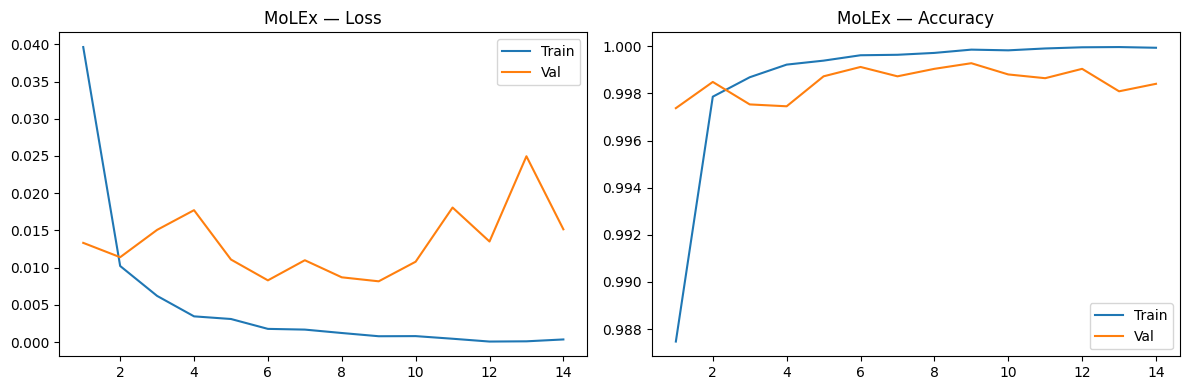

In [16]:
_ep = range(1, len(molex_history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(_ep, molex_history["train_loss"], label="Train")
axes[0].plot(_ep, molex_history["val_loss"],   label="Val")
axes[0].set_title("MoLEx — Loss"); axes[0].legend()
axes[1].plot(_ep, molex_history["train_acc"],  label="Train")
axes[1].plot(_ep, molex_history["val_acc"],    label="Val")
axes[1].set_title("MoLEx — Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{DIR_MOLEX}/training_curve.png", dpi=150); plt.show()


### 5.5 Evaluasi Test Set


In [17]:
import time

molex_model.load_state_dict(torch.load(molex_ckpt, map_location=DEVICE))
molex_model.eval()

m_preds, m_labels, m_probs = [], [], []
t0 = time.perf_counter()
with torch.no_grad():
    for feats, lab in tqdm(test_dl_m, desc="MoLEx test"):
        logits = molex_model(feats.to(DEVICE))
        m_probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        m_preds.extend(logits.argmax(1).cpu().numpy())
        m_labels.extend(lab.numpy())
m_infer_time = time.perf_counter() - t0

m_labels, m_preds, m_probs = map(np.array, [m_labels, m_preds, m_probs])
molex_metrics = compute_metrics(m_labels, m_preds, m_probs)
molex_metrics["infer_time_s"]        = round(m_infer_time, 4)
molex_metrics["infer_ms_per_sample"] = round(m_infer_time / len(m_labels) * 1000, 4)

print(classification_report(m_labels, m_preds, target_names=["bonafide", "spoof"]))
print(f"ROC-AUC      : {molex_metrics['roc_auc']:.4f}")
print(f"EER          : {molex_metrics['eer']*100:.2f}%")
print(f"MCC          : {molex_metrics['mcc']:.4f}")
print(f"Waktu inf.   : {m_infer_time*1000:.1f} ms total  |  "
      f"{molex_metrics['infer_ms_per_sample']:.4f} ms/sampel")
json.dump(molex_metrics, open(f"{DIR_MOLEX}/test_results.json", "w"), indent=2)
np.savez(f"{DIR_MOLEX}/test_predictions.npz",
         labels=m_labels, preds=m_preds, probs=m_probs)


MoLEx test:   0%|          | 0/394 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    bonafide       1.00      1.00      1.00      6334
       spoof       1.00      1.00      1.00      6245

    accuracy                           1.00     12579
   macro avg       1.00      1.00      1.00     12579
weighted avg       1.00      1.00      1.00     12579

ROC-AUC      : 0.9999
EER          : 0.06%
MCC          : 0.9990
Waktu inf.   : 43443.1 ms total  |  3.4536 ms/sampel


---
## Bagian 6 — Evaluasi Komparatif AASIST vs MoLEx


### 6.1 Visualisasi ROC, Confusion Matrix, Learning Curves


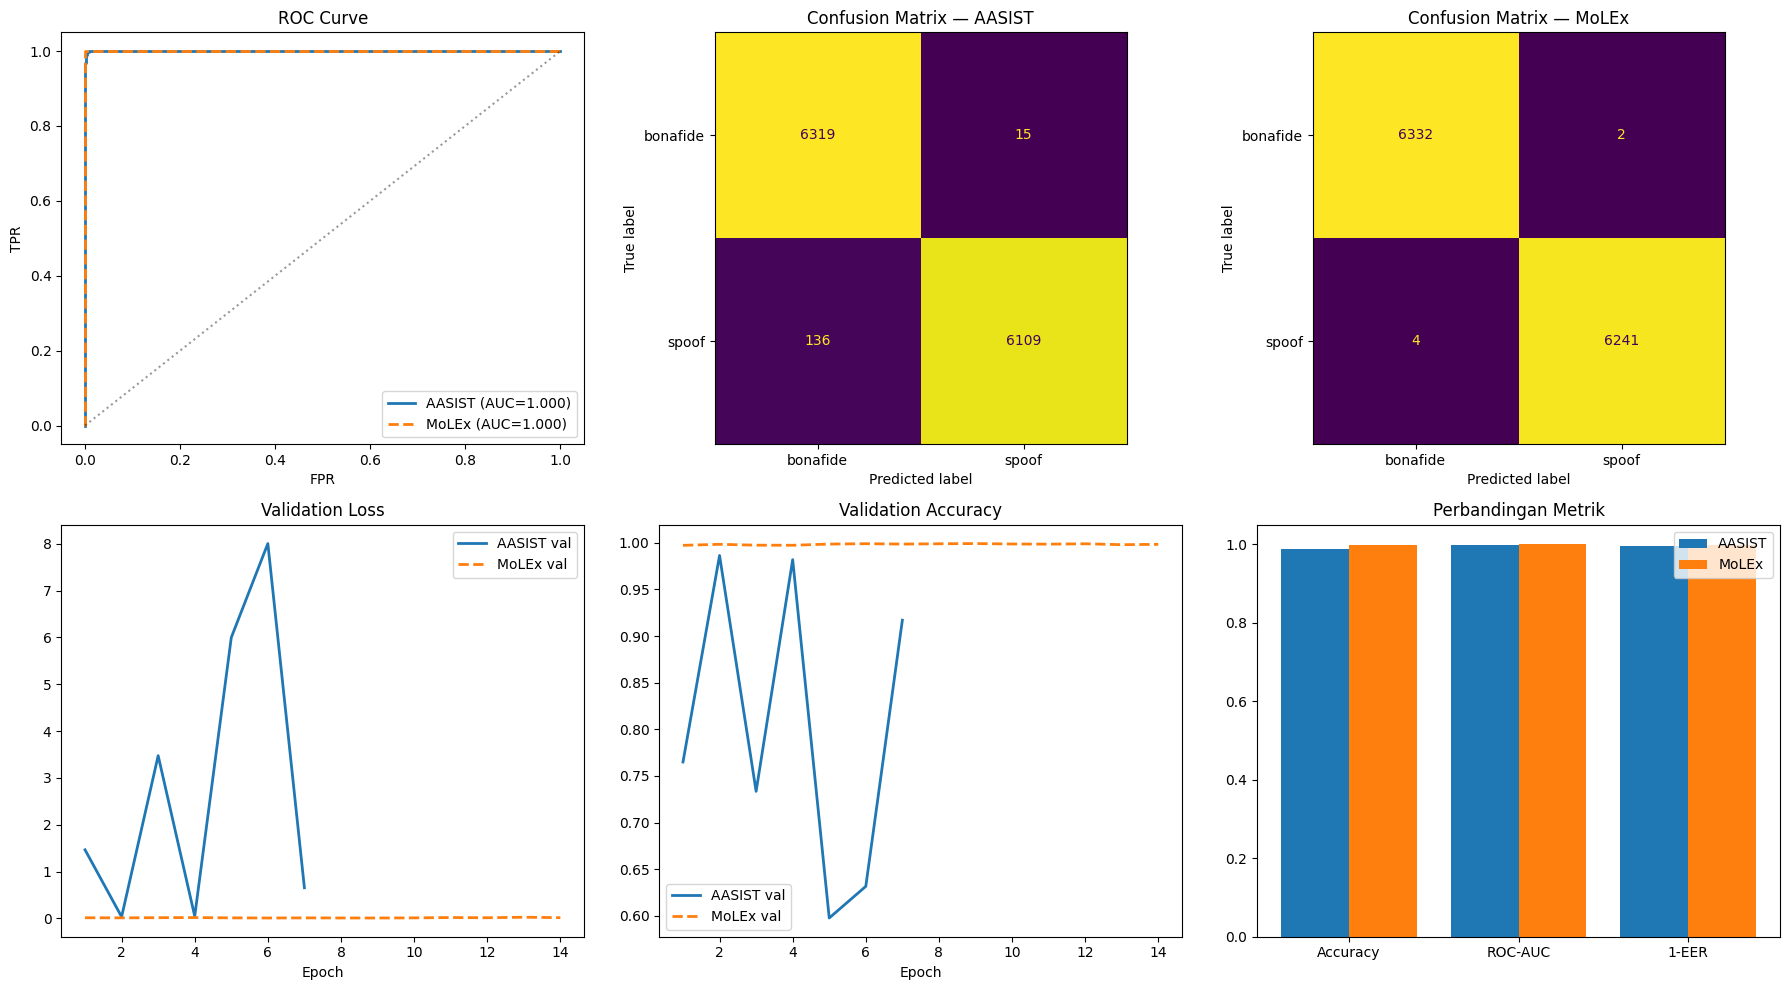

In [18]:
# ── Bootstrap: jalankan Bagian 6 tanpa re-run cell sebelumnya ──
from shared.bootstrap import *

# Load hasil test AASIST + MoLEx dari disk
a_labels, a_preds, a_probs, aasist_metrics = load_test_predictions("aasist")
m_labels, m_preds, m_probs, molex_metrics  = load_test_predictions("molex")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

def _load_hist(path):
    with open(path) as f: return json.load(f)

h_a = _load_hist(f"{DIR_AASIST}/history.json")
h_m = _load_hist(f"{DIR_MOLEX}/history.json")

fpr_a, tpr_a, _ = roc_curve(a_labels, a_probs)
fpr_m, tpr_m, _ = roc_curve(m_labels, m_probs)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr_a, tpr_a, lw=2, label=f"AASIST (AUC={aasist_metrics['roc_auc']:.3f})")
ax1.plot(fpr_m, tpr_m, lw=2, ls="--", label=f"MoLEx (AUC={molex_metrics['roc_auc']:.3f})")
ax1.plot([0,1],[0,1],"k:",alpha=0.4)
ax1.set_title("ROC Curve"); ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR"); ax1.legend()

# Confusion Matrix AASIST
ax2 = fig.add_subplot(gs[0, 1])
ConfusionMatrixDisplay(confusion_matrix(a_labels, a_preds),
                        display_labels=["bonafide","spoof"]).plot(ax=ax2, colorbar=False)
ax2.set_title("Confusion Matrix — AASIST")

# Confusion Matrix MoLEx
ax3 = fig.add_subplot(gs[0, 2])
ConfusionMatrixDisplay(confusion_matrix(m_labels, m_preds),
                        display_labels=["bonafide","spoof"]).plot(ax=ax3, colorbar=False)
ax3.set_title("Confusion Matrix — MoLEx")

# Val Loss
ea = range(1, len(h_a["val_loss"])+1)
em = range(1, len(h_m["val_loss"])+1)
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(ea, h_a["val_loss"], lw=2, label="AASIST val")
ax4.plot(em, h_m["val_loss"], lw=2, ls="--", label="MoLEx val")
ax4.set_title("Validation Loss"); ax4.set_xlabel("Epoch"); ax4.legend()

# Val Accuracy
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(ea, h_a["val_acc"], lw=2, label="AASIST val")
ax5.plot(em, h_m["val_acc"], lw=2, ls="--", label="MoLEx val")
ax5.set_title("Validation Accuracy"); ax5.set_xlabel("Epoch"); ax5.legend()

# Bar perbandingan metrik
ax6 = fig.add_subplot(gs[1, 2])
mn  = ["Accuracy", "ROC-AUC", "1-EER"]
va  = [aasist_metrics["accuracy"], aasist_metrics["roc_auc"], 1-aasist_metrics["eer"]]
vm  = [molex_metrics["accuracy"],  molex_metrics["roc_auc"],  1-molex_metrics["eer"]]
xb  = np.arange(len(mn))
ax6.bar(xb-0.2, va, 0.4, label="AASIST")
ax6.bar(xb+0.2, vm, 0.4, label="MoLEx")
ax6.set_xticks(xb); ax6.set_xticklabels(mn)
ax6.set_ylim(0, 1.05); ax6.set_title("Perbandingan Metrik"); ax6.legend()

plt.tight_layout()
plt.savefig(f"{DIR_COMPARE}/comparison.png", dpi=150); plt.show()


### 6.2 Ringkasan Tabel


In [19]:
summary_compare = {
    "AASIST": {"accuracy": round(aasist_metrics["accuracy"],4),
               "roc_auc" : round(aasist_metrics["roc_auc"],4),
               "eer_pct" : round(aasist_metrics["eer"]*100,2),
               "mcc"     : round(aasist_metrics["mcc"],4),
               "infer_ms": round(aasist_metrics.get("infer_ms_per_sample",0),4)},
    "MoLEx" : {"accuracy": round(molex_metrics["accuracy"],4),
               "roc_auc" : round(molex_metrics["roc_auc"],4),
               "eer_pct" : round(molex_metrics["eer"]*100,2),
               "mcc"     : round(molex_metrics["mcc"],4),
               "infer_ms": round(molex_metrics.get("infer_ms_per_sample",0),4)},
}

print("╔════════════════════════════════════════════════════════════════════════╗")
print("║              RINGKASAN KOMPARATIF MODEL                               ║")
print("╠══════════════╦══════════╦══════════╦═══════════╦════════╦════════════╣")
print("║ Model        ║ Accuracy ║ ROC-AUC  ║ EER (%)   ║  MCC   ║ ms/sampel  ║")
print("╠══════════════╬══════════╬══════════╬═══════════╬════════╬════════════╣")
for name, m in summary_compare.items():
    print(f"║ {name:12s} ║ {m['accuracy']*100:6.2f}%  ║ {m['roc_auc']:8.4f} ║ "
          f"{m['eer_pct']:7.2f}%   ║ {m['mcc']:6.4f} ║ {m['infer_ms']:10.4f} ║")
print("╚══════════════╩══════════╩══════════╩═══════════╩════════╩════════════╝")

json.dump(summary_compare, open(f"{DIR_COMPARE}/comparison_summary.json","w"), indent=2)
print(f"\n✅ Disimpan ke {DIR_COMPARE}/comparison_summary.json")


╔════════════════════════════════════════════════════════════════════════╗
║              RINGKASAN KOMPARATIF MODEL                               ║
╠══════════════╦══════════╦══════════╦═══════════╦════════╦════════════╣
║ Model        ║ Accuracy ║ ROC-AUC  ║ EER (%)   ║  MCC   ║ ms/sampel  ║
╠══════════════╬══════════╬══════════╬═══════════╬════════╬════════════╣
║ AASIST       ║  98.80%  ║   0.9998 ║    0.43%   ║ 0.9762 ║     4.7247 ║
║ MoLEx        ║  99.95%  ║   0.9999 ║    0.06%   ║ 0.9990 ║     3.4536 ║
╚══════════════╩══════════╩══════════╩═══════════╩════════╩════════════╝

✅ Disimpan ke /Users/rey/ITB/semester_2/PPT/models_voice/comparison/comparison_summary.json


---
## Bagian 7 — Real-World Inference Test

Prediksi file audio nyata menggunakan kedua model + ensemble voting.


### 7.1 Load Model & Fungsi Prediksi
> Model dimuat ulang dari checkpoint sehingga bagian ini bisa dijalankan independen.


In [20]:
# ── Bootstrap: jalankan bagian ini tanpa re-run cell sebelumnya ──
from shared.bootstrap import *
from shared.datasets import AudioDataset, LFCCDataset
from shared.models import AASIST, MoLEx

import torchaudio.transforms as T

# ── Load checkpoint ─────────────────────────────────────────────
rw_aasist = AASIST().to(DEVICE)
rw_aasist.load_state_dict(torch.load(f"{DIR_AASIST}/aasist_best.pt", map_location=DEVICE))
rw_aasist.eval()

rw_molex = MoLEx(n_lfcc=N_LFCC).to(DEVICE)
rw_molex.load_state_dict(torch.load(f"{DIR_MOLEX}/molex_best.pt", map_location=DEVICE))
rw_molex.eval()

lfcc_xfm = T.LFCC(
    sample_rate=SAMPLE_RATE, n_lfcc=N_LFCC, n_filter=N_FILTER,
    speckwargs={"n_fft": N_FFT, "win_length": WIN_LENGTH, "hop_length": HOP_LENGTH},
)
print("✅ Model dimuat")


# ── Helper ─────────────────────────────────────────────────────
def _load_audio_rw(path: str) -> torch.Tensor:
    """Load audio → mono 16 kHz → pad/crop MAX_SAMPLES. Return [1, T]."""
    wf, sr = torchaudio.load(path)
    if wf.shape[0] > 1: wf = wf.mean(0, keepdim=True)
    if sr != SAMPLE_RATE:
        wf = torchaudio.functional.resample(wf, sr, SAMPLE_RATE)
    T_len = wf.shape[1]
    if T_len < MAX_SAMPLES:
        wf = torch.nn.functional.pad(wf, (0, MAX_SAMPLES - T_len))
    else:
        wf = wf[:, :MAX_SAMPLES]
    return wf   # [1, T]


def _cmvn(lfcc: torch.Tensor) -> torch.Tensor:
    """Cepstral Mean-Variance Normalization per utterance. Input: [1, n_lfcc, frames]"""
    mean = lfcc.mean(dim=-1, keepdim=True)
    std  = lfcc.std(dim=-1, keepdim=True).clamp(min=1e-8)
    return (lfcc - mean) / std


def _verdict(p_spoof: float) -> str:
    if p_spoof >= THRESH_HIGH: return "SPOOF"
    if p_spoof <= THRESH_LOW:  return "BONAFIDE"
    return "TIDAK YAKIN"


@torch.no_grad()
def predict_file(audio_path: str) -> dict:
    """Prediksi satu file audio → AASIST + MoLEx + ensemble."""
    wf       = _load_audio_rw(audio_path)
    prob_a   = torch.softmax(rw_aasist(wf.squeeze(0).unsqueeze(0).to(DEVICE)), 1)[0].cpu().numpy()
    lfcc     = _cmvn(lfcc_xfm(wf))   # CMVN agar konsisten dengan training
    prob_m   = torch.softmax(rw_molex(lfcc.to(DEVICE)), 1)[0].cpu().numpy()
    prob_ens = (prob_a + prob_m) / 2
    return {
        "file"            : Path(audio_path).name,
        "aasist_p_spoof"  : float(prob_a[1]),
        "aasist_label"    : _verdict(float(prob_a[1])),
        "molex_p_spoof"   : float(prob_m[1]),
        "molex_label"     : _verdict(float(prob_m[1])),
        "ensemble_p_spoof": float(prob_ens[1]),
        "ensemble_label"  : _verdict(float(prob_ens[1])),
    }


def print_prediction(r: dict):
    print(f"{chr(9472)*52}")
    print(f"  File     : {r['file']}")
    print(f"{chr(9472)*52}")
    print(f"  AASIST   : {r['aasist_label']:12s}  (p_spoof={r['aasist_p_spoof']:.4f})")
    print(f"  MoLEx    : {r['molex_label']:12s}  (p_spoof={r['molex_p_spoof']:.4f})")
    print(f"  Ensemble : {r['ensemble_label']:12s}  (p_spoof={r['ensemble_p_spoof']:.4f})")
    print(f"{chr(9472)*52}")

print("✅ Fungsi prediksi siap")

✅ Model dimuat
✅ Fungsi prediksi siap


### 7.2 Prediksi Satu File
> Ganti `AUDIO_PATH` dengan path file yang ingin diuji.


────────────────────────────────────────────────────
  File     : sample_gtid.mp3
────────────────────────────────────────────────────
  AASIST   : BONAFIDE      (p_spoof=0.0000)
  MoLEx    : BONAFIDE      (p_spoof=0.0000)
  Ensemble : BONAFIDE      (p_spoof=0.0000)
────────────────────────────────────────────────────


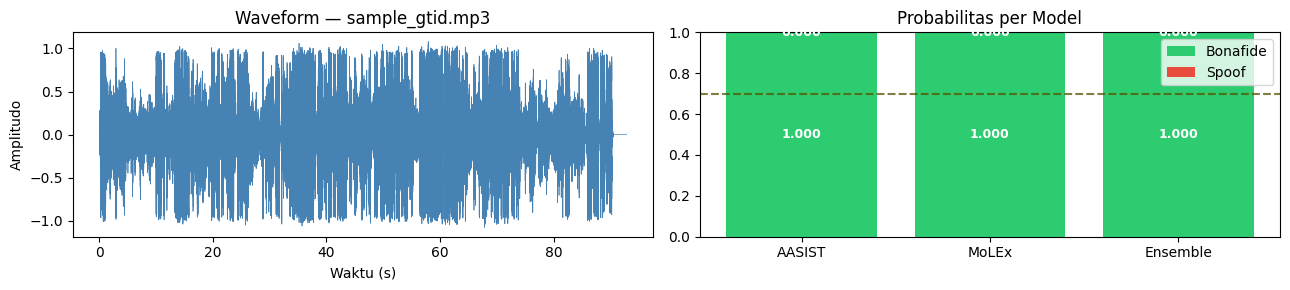

In [21]:
AUDIO_PATH = "/Users/rey/ITB/semester_2/PPT/test_audio/sample_gtid.mp3"

if not os.path.exists(AUDIO_PATH):
    print(f"❌ File tidak ditemukan: {AUDIO_PATH}")
else:
    result = predict_file(AUDIO_PATH)
    print_prediction(result)

    wf, sr = torchaudio.load(AUDIO_PATH)
    if wf.shape[0] > 1: wf = wf.mean(0, keepdim=True)
    if sr != SAMPLE_RATE: wf = torchaudio.functional.resample(wf, sr, SAMPLE_RATE)

    fig, axes = plt.subplots(1, 2, figsize=(13, 3))
    t = np.linspace(0, wf.shape[1]/SAMPLE_RATE, wf.shape[1])
    axes[0].plot(t, wf[0].numpy(), lw=0.5, color="steelblue")
    axes[0].set_title(f"Waveform — {Path(AUDIO_PATH).name}")
    axes[0].set_xlabel("Waktu (s)"); axes[0].set_ylabel("Amplitudo")

    models_lbl = ["AASIST", "MoLEx", "Ensemble"]
    p_sp = [result["aasist_p_spoof"], result["molex_p_spoof"], result["ensemble_p_spoof"]]
    p_bf = [1-p for p in p_sp]
    xb   = np.arange(3)
    axes[1].bar(xb, p_bf, label="Bonafide", color="#2ecc71")
    axes[1].bar(xb, p_sp, bottom=p_bf, label="Spoof", color="#e74c3c")
    axes[1].axhline(THRESH_HIGH, color="red",   ls="--", alpha=0.5)
    axes[1].axhline(1-THRESH_LOW, color="green", ls="--", alpha=0.5)
    axes[1].set_xticks(xb); axes[1].set_xticklabels(models_lbl)
    axes[1].set_ylim(0, 1); axes[1].set_title("Probabilitas per Model"); axes[1].legend()
    for i, (pb, ps) in enumerate(zip(p_bf, p_sp)):
        axes[1].text(i, pb/2,    f"{pb:.3f}", ha="center", va="center",
                      color="white", fontsize=9, fontweight="bold")
        axes[1].text(i, pb+ps/2, f"{ps:.3f}", ha="center", va="center",
                      color="white", fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{DIR_REALWORLD}/{Path(AUDIO_PATH).stem}_result.png", dpi=150); plt.show()


### 7.3 Prediksi Batch Folder
> Ganti `AUDIO_FOLDER` dengan folder berisi file audio.


In [22]:
AUDIO_FOLDER  = "/Users/rey/ITB/semester_2/PPT/test_audio"
SUPPORTED_EXT = {".flac", ".wav", ".mp3", ".m4a", ".ogg"}

audio_files = sorted(
    p for p in Path(AUDIO_FOLDER).iterdir()
    if p.suffix.lower() in SUPPORTED_EXT
)

if not audio_files:
    print(f"❌ Tidak ada file audio di: {AUDIO_FOLDER}")
else:
    batch_results = []
    for ap in tqdm(audio_files, desc="Inferensi batch"):
        try:
            batch_results.append(predict_file(str(ap)))
        except Exception as e:
            print(f"[ERROR] {ap.name}: {e}")

    for r in batch_results:
        print_prediction(r)

    csv_path   = f"{DIR_REALWORLD}/batch_results.csv"
    fieldnames = ["file","aasist_label","aasist_p_spoof",
                   "molex_label","molex_p_spoof",
                   "ensemble_label","ensemble_p_spoof"]
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        w.writeheader(); w.writerows(batch_results)
    print(f"\n✅ Hasil disimpan ke: {csv_path}")


Inferensi batch:   0%|          | 0/25 [00:00<?, ?it/s]

────────────────────────────────────────────────────
  File     : fake_ardi_ttsfree.mp3
────────────────────────────────────────────────────
  AASIST   : SPOOF         (p_spoof=0.9408)
  MoLEx    : SPOOF         (p_spoof=1.0000)
  Ensemble : SPOOF         (p_spoof=0.9704)
────────────────────────────────────────────────────
────────────────────────────────────────────────────
  File     : fake_guru_rani_minta_duit.mp3
────────────────────────────────────────────────────
  AASIST   : SPOOF         (p_spoof=0.9915)
  MoLEx    : BONAFIDE      (p_spoof=0.0000)
  Ensemble : TIDAK YAKIN   (p_spoof=0.4958)
────────────────────────────────────────────────────
────────────────────────────────────────────────────
  File     : fake_rani_ttsfree.mp3
────────────────────────────────────────────────────
  AASIST   : SPOOF         (p_spoof=1.0000)
  MoLEx    : SPOOF         (p_spoof=1.0000)
  Ensemble : SPOOF         (p_spoof=1.0000)
────────────────────────────────────────────────────
──────────────

### 7.4 Plot Ringkasan Batch


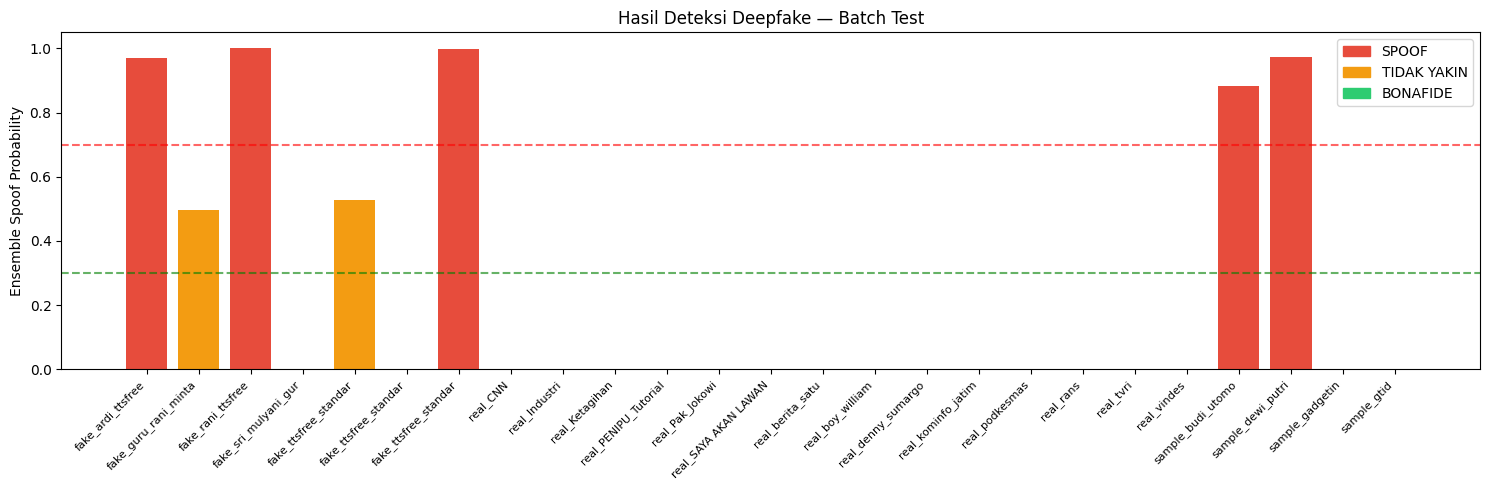

SPOOF       : 5  (20.0%)
BONAFIDE    : 18  (72.0%)
TIDAK YAKIN : 2  (8.0%)


In [23]:
if "batch_results" in dir() and batch_results:
    files     = [r["file"] for r in batch_results]
    ens_probs = [r["ensemble_p_spoof"] for r in batch_results]
    colors    = [
        "#e74c3c" if p >= THRESH_HIGH
        else "#f39c12" if p > THRESH_LOW
        else "#2ecc71"
        for p in ens_probs
    ]

    fig, ax = plt.subplots(figsize=(max(10, len(files)*0.6), 5))
    ax.bar(range(len(files)), ens_probs, color=colors)
    ax.axhline(THRESH_HIGH, color="red",   ls="--", alpha=0.6)
    ax.axhline(THRESH_LOW,  color="green", ls="--", alpha=0.6)
    ax.set_xticks(range(len(files)))
    ax.set_xticklabels([Path(f).stem[:20] for f in files], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Ensemble Spoof Probability")
    ax.set_title("Hasil Deteksi Deepfake — Batch Test")
    ax.set_ylim(0, 1.05)
    ax.legend(handles=[
        mpatches.Patch(color="#e74c3c", label="SPOOF"),
        mpatches.Patch(color="#f39c12", label="TIDAK YAKIN"),
        mpatches.Patch(color="#2ecc71", label="BONAFIDE"),
    ], loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{DIR_REALWORLD}/batch_summary.png", dpi=150); plt.show()

    n_s = sum(1 for p in ens_probs if p >= THRESH_HIGH)
    n_b = sum(1 for p in ens_probs if p <= THRESH_LOW)
    n_u = len(ens_probs) - n_s - n_b
    print(f"SPOOF       : {n_s}  ({n_s/len(ens_probs)*100:.1f}%)")
    print(f"BONAFIDE    : {n_b}  ({n_b/len(ens_probs)*100:.1f}%)")
    print(f"TIDAK YAKIN : {n_u}  ({n_u/len(ens_probs)*100:.1f}%)")


---
## Bagian 8 — Ekstraksi Fitur untuk XGBoost

**26 fitur per file audio:**
`Chroma` · `RMS` · `Centroid` · `Bandwidth` · `Rolloff` · `ZCR` · `MFCC 1–20`

Setiap file dibagi per segmen 1 detik; fitur dirata-ratakan antar segmen.


### 8.1 Ekstraksi Fitur per Split


In [24]:
# ── Bootstrap: jalankan bagian ini tanpa re-run cell sebelumnya ──
from shared.bootstrap import *
import gc
from shared.feature_extraction import extract_features_from_file

FEATURE_NAMES = (
    ["Chroma", "RMS", "Centroid", "Bandwidth", "Rolloff", "ZCR"] +
    [f"MFCC_{i+1}" for i in range(N_MFCC)]
)


def _process_split_features(split_name: str):
    tsv_path = f"{SPLITS_DIR}/{split_name}.tsv"
    with open(tsv_path, "r", encoding="utf-8") as f:
        records = list(csv.DictReader(f, delimiter="\t"))

    X, y, ids, errors = [], [], [], 0
    for i, rec in enumerate(tqdm(records, desc=f"{split_name:5s}", unit="file")):
        fp    = rec["file_path"]
        label = 0 if rec["label"] == "bonafide" else 1
        if not os.path.exists(fp):
            errors += 1
            continue
        if i % 2000 == 0 and i > 0:
            gc.collect()
        try:
            feat = extract_features_from_file(
                fp, SAMPLE_RATE, SEGMENT_LEN, N_MFCC, XGB_N_FFT, XGB_HOP_LENGTH
            )
            X.append(feat); y.append(label); ids.append(rec["file_id"])
        except Exception:
            errors += 1
    print(f"  → {len(X):,} berhasil | {errors} error")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), ids


print("Mulai ekstraksi fitur...\n")
X_train_raw, y_train, ids_train = _process_split_features("train")
X_val_raw,   y_val,   ids_val   = _process_split_features("val")
X_test_raw,  y_test,  ids_test  = _process_split_features("test")

print(f"\nX_train={X_train_raw.shape} | X_val={X_val_raw.shape} | X_test={X_test_raw.shape}")


Mulai ekstraksi fitur...



train:   0%|          | 0/100622 [00:00<?, ?file/s]

  → 100,622 berhasil | 0 error


val  :   0%|          | 0/12577 [00:00<?, ?file/s]

  → 12,577 berhasil | 0 error


test :   0%|          | 0/12579 [00:00<?, ?file/s]

  → 12,579 berhasil | 0 error

X_train=(100622, 26) | X_val=(12577, 26) | X_test=(12579, 26)


### 8.2 Standardisasi & Simpan ke Disk


In [25]:
import joblib
from sklearn.preprocessing import StandardScaler

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_val_sc   = scaler.transform(X_val_raw)
X_test_sc  = scaler.transform(X_test_raw)

joblib.dump(scaler, f"{FEATURES_DIR}/scaler.pkl")
print("Scaler disimpan")

for name, X, y, ids in [
    ("train", X_train_sc, y_train, ids_train),
    ("val",   X_val_sc,   y_val,   ids_val),
    ("test",  X_test_sc,  y_test,  ids_test),
]:
    path = f"{FEATURES_DIR}/features_{name}.npz"
    np.savez_compressed(path, X=X, y=y, ids=ids)
    print(f"  {name:5s}.npz : {os.path.getsize(path)/1e6:.1f} MB")

print("✅ Semua fitur tersimpan")


Scaler disimpan
  train.npz : 10.7 MB
  val  .npz : 1.3 MB
  test .npz : 1.3 MB
✅ Semua fitur tersimpan


### 8.3 Analisis Fitur — Diskriminasi Kelas

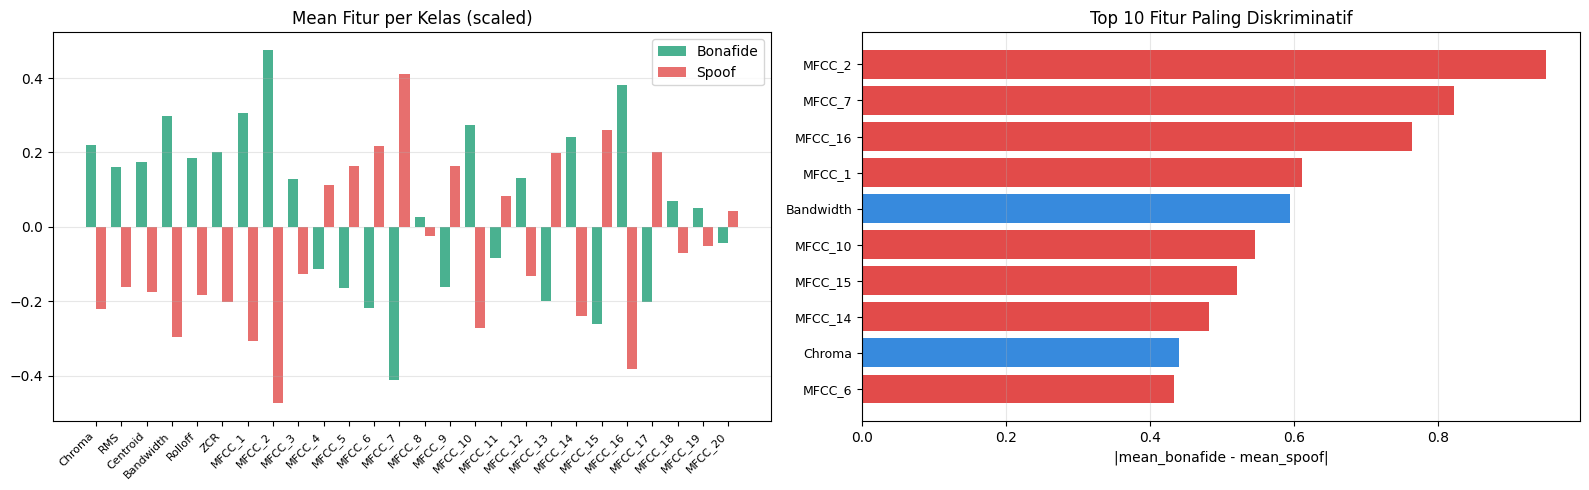

Top 10 fitur:
   1. MFCC_2          | delta=0.9501
   2. MFCC_7          | delta=0.8231
   3. MFCC_16         | delta=0.7646
   4. MFCC_1          | delta=0.6117
   5. Bandwidth       | delta=0.5945
   6. MFCC_10         | delta=0.5458
   7. MFCC_15         | delta=0.5211
   8. MFCC_14         | delta=0.4821
   9. Chroma          | delta=0.4395
  10. MFCC_6          | delta=0.4337


In [26]:
bf_mask = y_train == 0; sp_mask = y_train == 1
mean_bf = X_train_sc[bf_mask].mean(0)
mean_sp = X_train_sc[sp_mask].mean(0)
diff    = np.abs(mean_bf - mean_sp)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

xb = np.arange(len(FEATURE_NAMES))
axes[0].bar(xb-0.2, mean_bf, 0.4, label="Bonafide", color="#1d9e75", alpha=0.8)
axes[0].bar(xb+0.2, mean_sp, 0.4, label="Spoof",    color="#e24b4a", alpha=0.8)
axes[0].set_xticks(xb); axes[0].set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=8)
axes[0].set_title("Mean Fitur per Kelas (scaled)"); axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

top10_idx   = np.argsort(diff)[::-1][:10]
top10_names = [FEATURE_NAMES[i] for i in top10_idx]
top10_diff  = diff[top10_idx]
c10 = ["#e24b4a" if "MFCC" in n else "#378add" for n in top10_names]
axes[1].barh(range(10), top10_diff[::-1], color=c10[::-1])
axes[1].set_yticks(range(10)); axes[1].set_yticklabels(top10_names[::-1], fontsize=9)
axes[1].set_title("Top 10 Fitur Paling Diskriminatif")
axes[1].set_xlabel("|mean_bonafide - mean_spoof|"); axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FEATURES_DIR}/feature_analysis.png", dpi=150); plt.show()

print("Top 10 fitur:")
for rank, idx in enumerate(np.argsort(diff)[::-1][:10], 1):
    print(f"  {rank:2d}. {FEATURE_NAMES[idx]:15s} | delta={diff[idx]:.4f}")


---
## Bagian 9 — Training & Evaluasi XGBoost


### 9.1 Load Fitur & Setup
> Sel ini memuat fitur dari disk jika variabel tidak ada di memori,
> sehingga Bagian 9 bisa dijalankan independen tanpa re-run Bagian 8.


In [27]:
# ── Bootstrap Bagian 9 (self-contained) ──────────────────────────────────
from shared.bootstrap import *
import gc
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Bebaskan memori sebelum XGBoost: hapus array mentah + model PyTorch dari MPS
for _v in ("X_train_raw", "X_val_raw", "X_test_raw",
           "aasist_model", "molex_model",
           "dtrain", "dval", "dtest", "d_full"):
    if _v in globals():
        del globals()[_v]
try:
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
except Exception:
    pass
gc.collect()

# Load fitur dari disk jika belum ada di memori
if "X_train_sc" not in globals():
    _feat = load_xgb_features()
    X_train_sc, y_train = _feat["X_train_sc"], _feat["y_train"]
    X_val_sc,   y_val   = _feat["X_val_sc"],   _feat["y_val"]
    X_test_sc,  y_test  = _feat["X_test_sc"],  _feat["y_test"]
    print("Fitur dimuat dari disk")

if "FEATURE_NAMES" not in globals():
    FEATURE_NAMES = (["Chroma","RMS","Centroid","Bandwidth","Rolloff","ZCR"] +
                     [f"MFCC_{i+1}" for i in range(N_MFCC)])

X_cv = np.vstack([X_train_sc, X_val_sc])
y_cv = np.concatenate([y_train, y_val])

XGB_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    seed=42,
    tree_method="hist",
    device="cpu",
    verbosity=0,
)

dtrain = xgb.DMatrix(X_train_sc, label=y_train, feature_names=FEATURE_NAMES)
dval   = xgb.DMatrix(X_val_sc,   label=y_val,   feature_names=FEATURE_NAMES)
dtest  = xgb.DMatrix(X_test_sc,  label=y_test,  feature_names=FEATURE_NAMES)

import psutil as _psutil
_mem = _psutil.virtual_memory()
print(f"X_train : {X_train_sc.shape} | y: {np.bincount(y_train)}")
print(f"X_cv    : {X_cv.shape}")
print(f"XGBoost version: {xgb.__version__}")
print(f"RAM  : {_mem.used/1e9:.1f} GB used / {_mem.total/1e9:.1f} GB total  ({_mem.percent:.0f}%)")


X_train : (100622, 26) | y: [50264 50358]
X_cv    : (113199, 26)
XGBoost version: 3.2.0
RAM  : 7.0 GB used / 17.2 GB total  (72%)


### 9.2 Boosting Round Search


Early stopping search (max 500 rounds, patience=50)...
[0]	val-logloss:0.62178
[1]	val-logloss:0.56188
[2]	val-logloss:0.50234
[3]	val-logloss:0.45425
[4]	val-logloss:0.41739
[5]	val-logloss:0.38337
[6]	val-logloss:0.35309
[7]	val-logloss:0.32117
[8]	val-logloss:0.29262
[9]	val-logloss:0.26840
[10]	val-logloss:0.24587
[11]	val-logloss:0.22856
[12]	val-logloss:0.21063
[13]	val-logloss:0.19433
[14]	val-logloss:0.18001
[15]	val-logloss:0.16819
[16]	val-logloss:0.15615
[17]	val-logloss:0.14741
[18]	val-logloss:0.13707
[19]	val-logloss:0.12745
[20]	val-logloss:0.12037
[21]	val-logloss:0.11237
[22]	val-logloss:0.10504
[23]	val-logloss:0.09931
[24]	val-logloss:0.09302
[25]	val-logloss:0.08738
[26]	val-logloss:0.08297
[27]	val-logloss:0.07927
[28]	val-logloss:0.07587
[29]	val-logloss:0.07138
[30]	val-logloss:0.06750
[31]	val-logloss:0.06369
[32]	val-logloss:0.06031
[33]	val-logloss:0.05697
[34]	val-logloss:0.05362
[35]	val-logloss:0.05094
[36]	val-logloss:0.04872
[37]	val-logloss:0.04632
[38]	

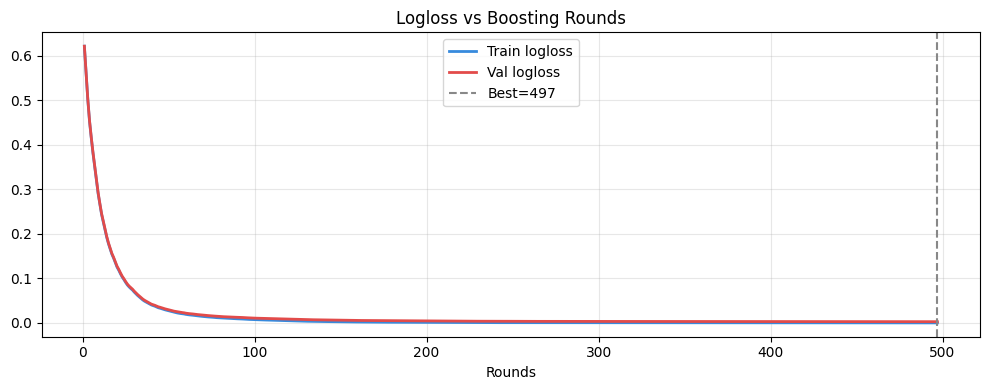

In [28]:
# Gunakan early stopping — 1 training run, bukan 41 loop terpisah
print(f"Early stopping search (max {XGB_ROUNDS_MAX} rounds, patience=50)...")

es_model = xgb.train(
    XGB_PARAMS,
    dtrain,
    num_boost_round=XGB_ROUNDS_MAX,
    evals=[(dval, "val")],
    early_stopping_rounds=50,
)
BEST_ROUNDS = es_model.best_iteration + 1
best_logloss = es_model.best_score
print(f"\nBest rounds={BEST_ROUNDS} | val_logloss={best_logloss:.4f}")
del es_model; gc.collect()

# Plot: learning curve dari evals_result
_es2 = xgb.train(
    XGB_PARAMS,
    dtrain,
    num_boost_round=BEST_ROUNDS,
    evals=[(dtrain, "train"), (dval, "val")],
    evals_result=(_evals_res := {}),
)
del _es2; gc.collect()

_rounds = range(1, BEST_ROUNDS + 1)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(_rounds, _evals_res["train"]["logloss"], color="#378add", lw=2, label="Train logloss")
ax.plot(_rounds, _evals_res["val"]["logloss"],   color="#e24b4a", lw=2, label="Val logloss")
ax.axvline(BEST_ROUNDS, color="#888", ls="--", label=f"Best={BEST_ROUNDS}")
ax.set_title("Logloss vs Boosting Rounds"); ax.set_xlabel("Rounds"); ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DIR_XGB}/round_search.png", dpi=150); plt.show()


### 9.3 10-Fold Cross-Validation


In [29]:
skf     = StratifiedKFold(n_splits=XGB_N_FOLDS, shuffle=True, random_state=42)
cv_accs, cv_aucs, cv_eers = [], [], []

for fold, (tr_idx, vl_idx) in enumerate(
        tqdm(skf.split(X_cv, y_cv), total=XGB_N_FOLDS, desc="10-Fold CV"), 1):

    d_tr = xgb.DMatrix(X_cv[tr_idx], label=y_cv[tr_idx], feature_names=FEATURE_NAMES)
    d_vl = xgb.DMatrix(X_cv[vl_idx], label=y_cv[vl_idx], feature_names=FEATURE_NAMES)
    fm    = xgb.train(XGB_PARAMS, d_tr, num_boost_round=BEST_ROUNDS)
    probs = fm.predict(d_vl)
    preds = (probs >= 0.5).astype(int)

    cv_accs.append(accuracy_score(y_cv[vl_idx], preds))
    cv_aucs.append(roc_auc_score(y_cv[vl_idx], probs))
    cv_eers.append(compute_eer(y_cv[vl_idx], probs))
    del d_tr, d_vl, fm; gc.collect()

print(f"\n10-Fold CV ({BEST_ROUNDS} rounds)")
print(f"  Accuracy : {np.mean(cv_accs)*100:.2f}% ± {np.std(cv_accs)*100:.2f}%")
print(f"  ROC-AUC  : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print(f"  EER      : {np.mean(cv_eers)*100:.2f}% ± {np.std(cv_eers)*100:.2f}%")


10-Fold CV:   0%|          | 0/10 [00:00<?, ?it/s]


10-Fold CV (497 rounds)
  Accuracy : 99.91% ± 0.02%
  ROC-AUC  : 1.0000 ± 0.0001
  EER      : 0.08% ± 0.03%


### 9.4 Training Model Final


In [30]:
import joblib

d_full    = xgb.DMatrix(X_cv, label=y_cv, feature_names=FEATURE_NAMES)
xgb_final = xgb.train(XGB_PARAMS, d_full, num_boost_round=BEST_ROUNDS)

xgb_final.save_model(f"{DIR_XGB}/xgboost_final.json")
joblib.dump(xgb_final, f"{DIR_XGB}/xgboost_final.pkl")
print(f"✅ Model disimpan ke {DIR_XGB}")


✅ Model disimpan ke /Users/rey/ITB/semester_2/PPT/models_voice/xgboost


### 9.5 Evaluasi Test Set


              precision    recall  f1-score   support

    bonafide       1.00      1.00      1.00      6334
       spoof       1.00      1.00      1.00      6245

    accuracy                           1.00     12579
   macro avg       1.00      1.00      1.00     12579
weighted avg       1.00      1.00      1.00     12579

ROC-AUC      : 1.0000
EER          : 0.04%
MCC          : 0.9992
Waktu inf.   : 55.9 ms total  |  0.0044 ms/sampel


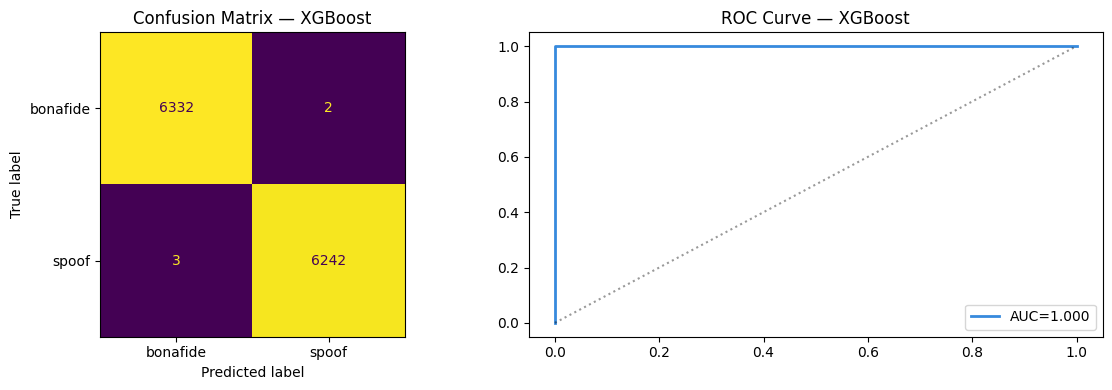

In [31]:
import time
from sklearn.metrics import classification_report

# Inferensi + ukur waktu
t0 = time.perf_counter()
xgb_probs = xgb_final.predict(dtest)
xgb_infer_time = time.perf_counter() - t0          # detik, seluruh test set
xgb_infer_ms   = xgb_infer_time / len(y_test) * 1000  # ms per sampel

xgb_preds = (xgb_probs >= 0.5).astype(int)
xgb_mets  = compute_metrics(y_test, xgb_preds, xgb_probs)
xgb_mets["infer_time_s"]  = round(xgb_infer_time, 4)
xgb_mets["infer_ms_per_sample"] = round(xgb_infer_ms, 4)

print(classification_report(y_test, xgb_preds, target_names=["bonafide","spoof"]))
print(f"ROC-AUC      : {xgb_mets['roc_auc']:.4f}")
print(f"EER          : {xgb_mets['eer']*100:.2f}%")
print(f"MCC          : {xgb_mets['mcc']:.4f}")
print(f"Waktu inf.   : {xgb_infer_time*1000:.1f} ms total  |  "
      f"{xgb_infer_ms:.4f} ms/sampel")

json.dump({**xgb_mets, "best_rounds": BEST_ROUNDS},
           open(f"{DIR_XGB}/test_results.json","w"), indent=2)

fpr_x, tpr_x, _ = roc_curve(y_test, xgb_probs)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, xgb_preds),
                        display_labels=["bonafide","spoof"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — XGBoost")
axes[1].plot(fpr_x, tpr_x, lw=2, color="#378add",
              label=f"AUC={xgb_mets['roc_auc']:.3f}")
axes[1].plot([0,1],[0,1],"k:",alpha=0.4)
axes[1].set_title("ROC Curve — XGBoost"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{DIR_XGB}/test_results.png", dpi=150); plt.show()


### 9.6 Feature Importance


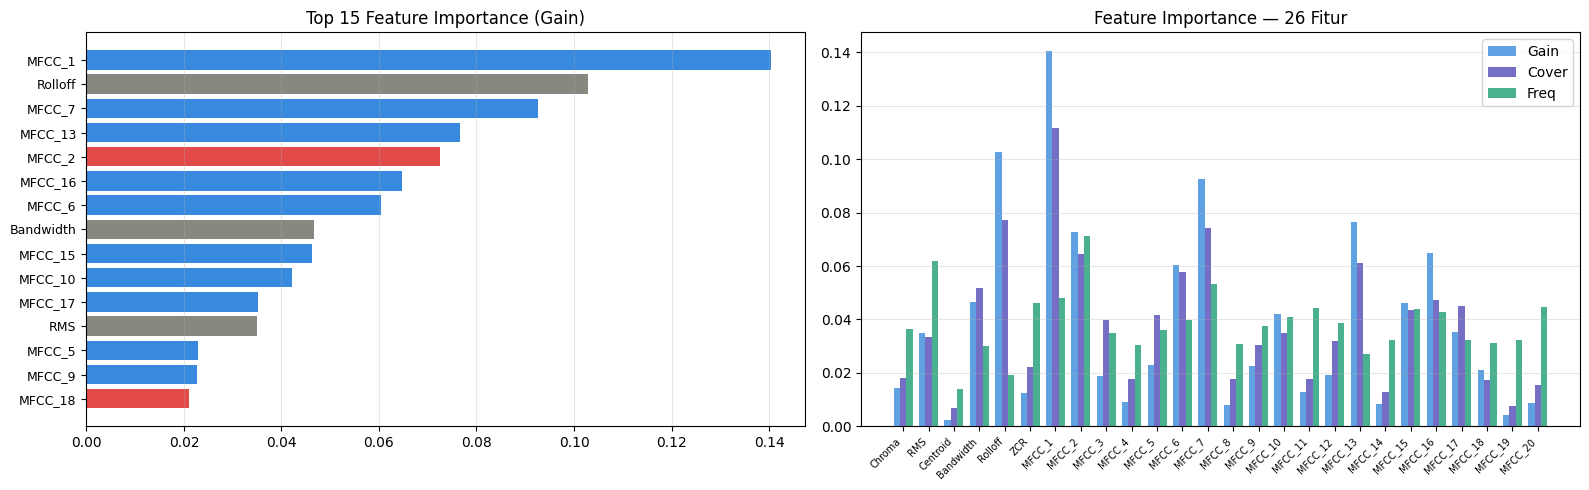

Top 10 fitur (Gain):
   1. MFCC_1          | gain=0.1405
   2. Rolloff         | gain=0.1029
   3. MFCC_7          | gain=0.0927
   4. MFCC_13         | gain=0.0766
   5. MFCC_2          | gain=0.0726
   6. MFCC_16         | gain=0.0648
   7. MFCC_6          | gain=0.0604
   8. Bandwidth       | gain=0.0467
   9. MFCC_15         | gain=0.0462
  10. MFCC_10         | gain=0.0421


In [32]:
imp_gain  = xgb_final.get_score(importance_type="gain")
imp_cover = xgb_final.get_score(importance_type="cover")
imp_freq  = xgb_final.get_score(importance_type="weight")

def _norm_imp(d):
    vals = np.array([d.get(f, 0) for f in FEATURE_NAMES])
    total = vals.sum()
    return vals / total if total > 0 else vals

gain_arr  = _norm_imp(imp_gain)
cover_arr = _norm_imp(imp_cover)
freq_arr  = _norm_imp(imp_freq)
top15_idx = np.argsort(gain_arr)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top15_names = [FEATURE_NAMES[i] for i in top15_idx]
colors = ["#e24b4a" if n in ("MFCC_2","MFCC_18") else "#378add" if "MFCC" in n else "#888780"
          for n in top15_names]
axes[0].barh(range(15), gain_arr[top15_idx][::-1], color=colors[::-1])
axes[0].set_yticks(range(15)); axes[0].set_yticklabels(top15_names[::-1], fontsize=9)
axes[0].set_title("Top 15 Feature Importance (Gain)"); axes[0].grid(axis="x", alpha=0.3)

xb = np.arange(len(FEATURE_NAMES))
axes[1].bar(xb-0.25, gain_arr,  0.25, label="Gain",  color="#378add", alpha=0.8)
axes[1].bar(xb,      cover_arr, 0.25, label="Cover", color="#534AB7", alpha=0.8)
axes[1].bar(xb+0.25, freq_arr,  0.25, label="Freq",  color="#1d9e75", alpha=0.8)
axes[1].set_xticks(xb); axes[1].set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=7)
axes[1].set_title("Feature Importance — 26 Fitur"); axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIR_XGB}/feature_importance.png", dpi=150); plt.show()

print("Top 10 fitur (Gain):")
for rank, idx in enumerate(np.argsort(gain_arr)[::-1][:10], 1):
    print(f"  {rank:2d}. {FEATURE_NAMES[idx]:15s} | gain={gain_arr[idx]:.4f}")


### 9.6b Inferensi Batch Folder — XGBoost
> Ganti `XGB_AUDIO_FOLDER` dengan folder berisi file audio yang ingin diuji.
> Sel ini **self-contained**: model XGBoost dan scaler dimuat ulang dari disk jika belum ada di memori.

XGBoost batch inferensi:   0%|          | 0/25 [00:00<?, ?it/s]

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?



File                                     Label          P(spoof)      ms
───────────────────────────────────────────────────────────────────────────
fake_ardi_ttsfree.mp3                    SPOOF            0.9820  172.37
fake_guru_rani_minta_duit.mp3            BONAFIDE         0.0024  342.74
fake_rani_ttsfree.mp3                    SPOOF            0.9999  172.73
fake_sri_mulyani_guru itu beban.mp3      BONAFIDE         0.0001   38.55
fake_ttsfree_standard-b.mp3              SPOOF            0.9327  158.12
fake_ttsfree_standard-c.mp3              BONAFIDE         0.0540  179.63
fake_ttsfree_standard-d.mp3              SPOOF            0.9865  190.57
real_CNN.mp3                             BONAFIDE         0.0000  294.03
real_Industri.mp3                        BONAFIDE         0.0000  2531.30
real_Ketagihan.mp3                       BONAFIDE         0.0000  103.02
real_PENIPU_Tutorial.mp3                 BONAFIDE         0.0000  1323.38
real_Pak_Jokowi.mp3                      BONA

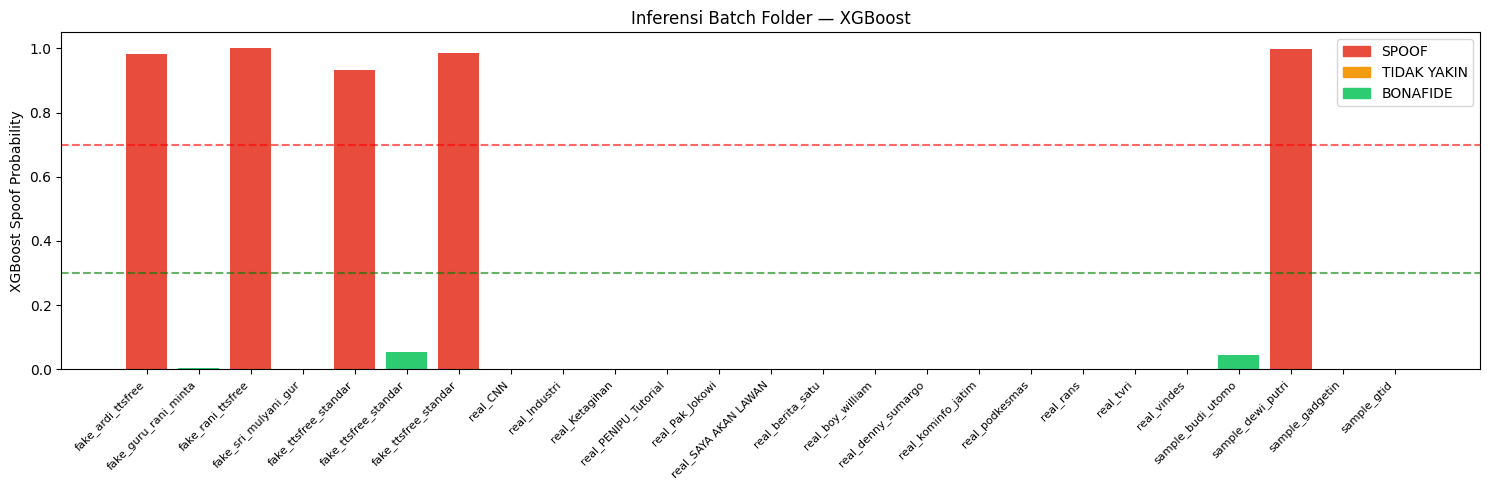


Ringkasan (25 file):
  SPOOF       : 5  (20.0%)
  BONAFIDE    : 20  (80.0%)
  TIDAK YAKIN : 0  (0.0%)
  Rata-rata waktu inferensi: 3310.595 ms/file

✅ Hasil disimpan ke: /Users/rey/ITB/semester_2/PPT/models_voice/xgboost/batch_results.csv


In [33]:
# ── Bootstrap & load artifacts ────────────────────────────────────────────
from shared.bootstrap import *
import joblib
import xgboost as xgb
import time
from shared.feature_extraction import extract_features_from_file

if "xgb_final" not in globals():
    _xgb_path = f"{DIR_XGB}/xgboost_final.json"
    if not os.path.exists(_xgb_path):
        raise FileNotFoundError(f"Model XGBoost belum ada — jalankan sel 9.4 dulu.")
    xgb_final = xgb.Booster()
    xgb_final.load_model(_xgb_path)
    print(f"✅ Model XGBoost dimuat dari {_xgb_path}")

if "scaler" not in globals():
    _scaler_path = f"{FEATURES_DIR}/scaler.pkl"
    if not os.path.exists(_scaler_path):
        raise FileNotFoundError(f"Scaler belum ada — jalankan sel 8.2 dulu.")
    scaler = joblib.load(_scaler_path)
    print(f"✅ Scaler dimuat dari {_scaler_path}")

if "FEATURE_NAMES" not in globals():
    FEATURE_NAMES = (["Chroma","RMS","Centroid","Bandwidth","Rolloff","ZCR"] +
                     [f"MFCC_{i+1}" for i in range(N_MFCC)])

# ── Konfigurasi folder ─────────────────────────────────────────────────────
XGB_AUDIO_FOLDER = "/Users/rey/ITB/semester_2/PPT/test_audio"
SUPPORTED_EXT    = {".flac", ".wav", ".mp3", ".m4a", ".ogg"}

audio_files = sorted(
    p for p in Path(XGB_AUDIO_FOLDER).iterdir()
    if p.suffix.lower() in SUPPORTED_EXT
)

if not audio_files:
    print(f"❌ Tidak ada file audio di: {XGB_AUDIO_FOLDER}")
else:
    xgb_batch_results = []
    for ap in tqdm(audio_files, desc="XGBoost batch inferensi"):
        try:
            t0 = time.perf_counter()
            raw_feat = extract_features_from_file(
                str(ap), sr=SAMPLE_RATE,
                n_mfcc=N_MFCC, n_fft=XGB_N_FFT, hop_length=XGB_HOP_LENGTH,
            )
            feat_sc = scaler.transform(raw_feat.reshape(1, -1))
            dmat    = xgb.DMatrix(feat_sc, feature_names=FEATURE_NAMES)
            p_spoof = float(xgb_final.predict(dmat)[0])
            infer_ms = (time.perf_counter() - t0) * 1000

            label = (
                "SPOOF"       if p_spoof >= THRESH_HIGH
                else "TIDAK YAKIN" if p_spoof >  THRESH_LOW
                else "BONAFIDE"
            )
            xgb_batch_results.append({
                "file":        str(ap),
                "xgb_label":   label,
                "xgb_p_spoof": round(p_spoof, 4),
                "infer_ms":    round(infer_ms, 3),
            })
        except Exception as e:
            print(f"[ERROR] {ap.name}: {e}")

    # ── Cetak hasil ────────────────────────────────────────────────────────
    print(f"\n{'File':<40} {'Label':<14} {'P(spoof)':>8}  {'ms':>6}")
    print("─" * 75)
    for r in xgb_batch_results:
        fname = Path(r["file"]).name[:38]
        print(f"{fname:<40} {r['xgb_label']:<14} {r['xgb_p_spoof']:>8.4f}  {r['infer_ms']:>6.2f}")

    # ── Simpan CSV ─────────────────────────────────────────────────────────
    csv_path = f"{DIR_XGB}/batch_results.csv"
    fieldnames = ["file", "xgb_label", "xgb_p_spoof", "infer_ms"]
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader(); w.writerows(xgb_batch_results)

    # ── Plot bar chart ─────────────────────────────────────────────────────
    file_stems = [Path(r["file"]).stem[:20] for r in xgb_batch_results]
    probs      = [r["xgb_p_spoof"] for r in xgb_batch_results]
    bar_colors = [
        "#e74c3c" if p >= THRESH_HIGH
        else "#f39c12" if p > THRESH_LOW
        else "#2ecc71"
        for p in probs
    ]

    fig, ax = plt.subplots(figsize=(max(10, len(file_stems) * 0.6), 5))
    ax.bar(range(len(file_stems)), probs, color=bar_colors)
    ax.axhline(THRESH_HIGH, color="red",   ls="--", alpha=0.6)
    ax.axhline(THRESH_LOW,  color="green", ls="--", alpha=0.6)
    ax.set_xticks(range(len(file_stems)))
    ax.set_xticklabels(file_stems, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("XGBoost Spoof Probability")
    ax.set_title("Inferensi Batch Folder — XGBoost")
    ax.set_ylim(0, 1.05)
    ax.legend(handles=[
        mpatches.Patch(color="#e74c3c", label="SPOOF"),
        mpatches.Patch(color="#f39c12", label="TIDAK YAKIN"),
        mpatches.Patch(color="#2ecc71", label="BONAFIDE"),
    ], loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{DIR_XGB}/batch_results.png", dpi=150)
    plt.show()

    # ── Ringkasan ──────────────────────────────────────────────────────────
    n_s = sum(1 for r in xgb_batch_results if r["xgb_p_spoof"] >= THRESH_HIGH)
    n_b = sum(1 for r in xgb_batch_results if r["xgb_p_spoof"] <= THRESH_LOW)
    n_u = len(xgb_batch_results) - n_s - n_b
    avg_ms = sum(r["infer_ms"] for r in xgb_batch_results) / len(xgb_batch_results)
    print(f"\nRingkasan ({len(xgb_batch_results)} file):")
    print(f"  SPOOF       : {n_s}  ({n_s/len(xgb_batch_results)*100:.1f}%)")
    print(f"  BONAFIDE    : {n_b}  ({n_b/len(xgb_batch_results)*100:.1f}%)")
    print(f"  TIDAK YAKIN : {n_u}  ({n_u/len(xgb_batch_results)*100:.1f}%)")
    print(f"  Rata-rata waktu inferensi: {avg_ms:.3f} ms/file")
    print(f"\n✅ Hasil disimpan ke: {csv_path}")


### 9.7 Perbandingan Ketiga Model

╔══════════════════════════════════════════════════════════════════════════════╗
║            PERBANDINGAN KETIGA MODEL — TEST SET                             ║
╠══════════════╦══════════╦══════════╦═══════════╦════════╦══════════════════╣
║ Model        ║ Accuracy ║ ROC-AUC  ║ EER (%)   ║  MCC   ║ Inf. (ms/sampel) ║
╠══════════════╬══════════╬══════════╬═══════════╬════════╬══════════════════╣
║ AASIST       ║  98.80%  ║   0.9998 ║    0.43%   ║ 0.9762 ║           4.7247 ║
║ MoLEx        ║  99.95%  ║   0.9999 ║    0.06%   ║ 0.9990 ║           3.4536 ║
║ XGBoost      ║  99.96%  ║   1.0000 ║    0.04%   ║ 0.9992 ║           0.0044 ║
╚══════════════╩══════════╩══════════╩═══════════╩════════╩══════════════════╝


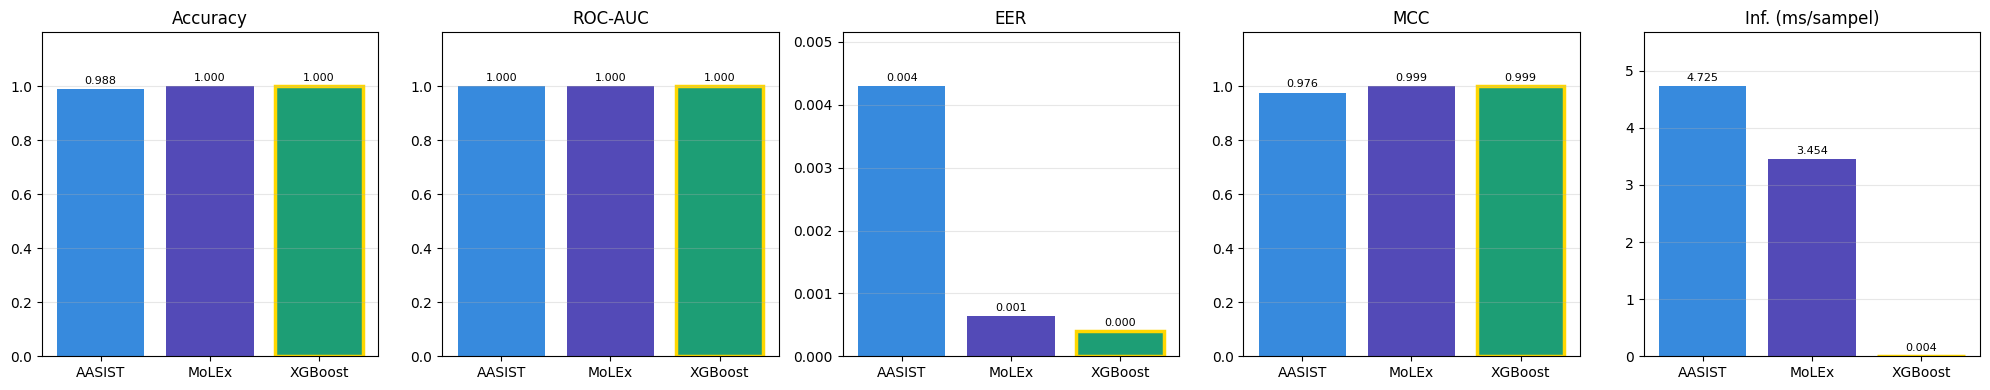

In [34]:
def _load_res(path):
    return json.load(open(path)) if os.path.exists(path) else None

all_model_res = [
    ("AASIST",  _load_res(f"{DIR_AASIST}/test_results.json")),
    ("MoLEx",   _load_res(f"{DIR_MOLEX}/test_results.json")),
    ("XGBoost", {**xgb_mets, "best_rounds": BEST_ROUNDS}),
]

print("╔══════════════════════════════════════════════════════════════════════════════╗")
print("║            PERBANDINGAN KETIGA MODEL — TEST SET                             ║")
print("╠══════════════╦══════════╦══════════╦═══════════╦════════╦══════════════════╣")
print("║ Model        ║ Accuracy ║ ROC-AUC  ║ EER (%)   ║  MCC   ║ Inf. (ms/sampel) ║")
print("╠══════════════╬══════════╬══════════╬═══════════╬════════╬══════════════════╣")
for name, res in all_model_res:
    if res:
        mcc_str  = f"{res.get('mcc', float('nan')):6.4f}"
        ms_str   = f"{res.get('infer_ms_per_sample', float('nan')):16.4f}"
        print(f"║ {name:12s} ║ {res['accuracy']*100:6.2f}%  ║ {res['roc_auc']:8.4f} ║ "
              f"{res['eer']*100:7.2f}%   ║ {mcc_str} ║ {ms_str} ║")
    else:
        print(f"║ {name:12s} ║ {'N/A':8s} ║ {'N/A':8s} ║ {'N/A':9s} ║ {'N/A':6s} ║ {'N/A':16s} ║")
print("╚══════════════╩══════════╩══════════╩═══════════╩════════╩══════════════════╝")

# Bar chart perbandingan (5 metrik)
valid = [(n, r) for n, r in all_model_res if r]
if valid:
    names  = [n for n, _ in valid]
    colors = ["#378add", "#534AB7", "#1d9e75"]
    metrics_cfg = [
        ("accuracy",           "Accuracy",         False),
        ("roc_auc",            "ROC-AUC",           False),
        ("eer",                "EER",               True),
        ("mcc",                "MCC",               False),
        ("infer_ms_per_sample","Inf. (ms/sampel)",  True),
    ]
    fig, axes = plt.subplots(1, len(metrics_cfg), figsize=(20, 4))
    for ax, (metric, label, lower_better) in zip(axes, metrics_cfg):
        vals = [r.get(metric, 0) for _, r in valid]
        bars = ax.bar(names, vals, color=colors[:len(vals)])
        ax.set_title(label)
        ax.set_ylim(0, max(vals) * 1.2 if max(vals) > 0 else 1)
        ax.grid(axis="y", alpha=0.3)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v + max(vals)*0.02,
                    f"{v:.3f}", ha="center", fontsize=8)
        best_val = min(vals) if lower_better else max(vals)
        best_idx = vals.index(best_val)
        bars[best_idx].set_edgecolor("gold"); bars[best_idx].set_linewidth(2.5)
    plt.tight_layout()
    plt.savefig(f"{DIR_COMPARE}/all_models_comparison.png", dpi=150); plt.show()
